# 🛒 电商用户行为分析：AARRR 框架下的用户增长与留存研究

> **数据来源**：Kaggle — Multi-Category Online Store Behavior Data（2019年10月+11月）  
> **原始规模**：约 1.1 亿行 · 531 万用户  
> **工具栈**：Python · DuckDB · scikit-learn · pantab / tableauhyperapi · Tableau  
> **目标**：通过 AARRR 框架还原用户生命周期，识别增长机会与流失节点，并构建复购潜力预测模型

🔗 **[点击查看 Tableau Interactive Dashboard](https://public.tableau.com/shared/34T6RQS35?:display_count=n&:origin=viz_share_link)**

---

## 分析模块

| Block | 内容 |
|---|---|
| ⚙️ | 全局路径配置（每次使用前修改此处） |
| 0 | 快速恢复块（Kernel 重启后只跑这一块，秒级恢复所有变量） |
| 1 | 数据读取 & 分层抽样（只跑一次） |
| 1.5 | 数据质量说明（品类缺失率、smart_repair 策略、抽样局限性）|
| 2 | 基础 EDA：价格分布 |
| 3 | 整体转化漏斗 |
| 4 | 品类转化漏斗 & 四象限气泡图 |
| 5 | RFM 用户分层 |
| 6 | Session 分析 |
| 7 | 决策链追溯（完整决策成本） |
| 8 | 专注度 × 决策风格交叉分析 |
| 9 | 活跃度分析（日活 / 大促量化 / 小时 / 周几） |
| 10 | Top5 品类 × 时间热力图 |
| 11 | RFM 分层 × 活跃度分析 |
| 12 | 决策风格 × 活跃度分析 |
| 13 | 用户留存分析（留存曲线 + RFM 分层对比） |
| 14 | Tableau 数据导出（T1 用户宽表 + T2 购买明细） |
| 15 | 复购预测逻辑回归模型（AUC = 0.799，无高泄露特征）+ T3 评分导出 |
| 16 | 首购后7天特征 → 无泄露复购预测模型（可部署版，预期 AUC 0.72–0.78）|
| 17 | 用户 LTV 估算（BG/NBD + Gamma-Gamma，获客成本上限推算）|
| 18 | 价格弹性分析（品类 × 价格档位，识别高/低弹性品类）|
| 19 | 品类共购分析（Market Basket Analysis，关联推荐策略支撑）|

---

**输出文件（3 个 Hyper）：**

| 文件 | 内容 | 行数 |
|---|---|---|
| `T1_fat_user.hyper` | 用户宽表（一人一行，40+ 字段） | 全量用户 |
| `T2_fact_purchases.hyper` | 购买明细（含三层品类 + 用户标签） | 约 500 万行 |
| `T3_repurchase_scores.hyper` | 复购潜力评分（高/中/低潜力分层） | 有购买行为用户 |


---
## ⚙️ 全局路径配置

**使用前请修改以下路径，其余代码无需改动。**

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙️  全局配置 — 使用前请修改以下两个路径
# ══════════════════════════════════════════════════════════════════════════════

# 原始 parquet 文件所在目录 & 中间结果保存目录（同一个目录即可）
DATA_PATH = "./data/"  # 请修改为原始 parquet 文件所在目录
BASE_PATH  = DATA_PATH   # alias used by Block 16-19

# Tableau Hyper 文件输出目录
OUTPUT_PATH = DATA_PATH + "hyper_v2/"
SAVE_PATH   = OUTPUT_PATH  # 图表保存路径
# 机器内存 × 0.75（DuckDB 导出大表时使用），16GB → "12GB"，32GB → "24GB"
MEMORY_LIMIT = "37GB"

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f"DATA_PATH   = {DATA_PATH}")
print(f"OUTPUT_PATH = {OUTPUT_PATH}")

DATA_PATH   = /Users/cristinayang/Desktop/ecommerce-analysis/
OUTPUT_PATH = /Users/cristinayang/Desktop/ecommerce-analysis/hyper_v2/


---
## 🔁 Block 0：快速恢复块

**每次重启 Kernel 只需跑这一块，几秒恢复所有变量（依赖 Block 1 已跑过并保存 parquet）。**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

# ── 读取已存好的抽样数据 & 中间结果 ──────────────────────────────
df_all         = pd.read_parquet(DATA_PATH + 'df_sample_30k.parquet')
rfm_table      = pd.read_parquet(DATA_PATH + 'rfm_table.parquet')
session_stats  = pd.read_parquet(DATA_PATH + 'session_stats.parquet')
session_clean  = pd.read_parquet(DATA_PATH + 'session_clean.parquet')
decision_chain = pd.read_parquet(DATA_PATH + 'decision_chain.parquet')

df = df_all

# ── 重建标签函数（apply 时需要定义） ─────────────────────────────
def label_style_v2(row):
    n = row['pre_session_count']
    if n == 0:    return '即时决策'
    elif n <= 2:  return '果断'
    elif n <= 5:  return '普通'
    else:         return '犹豫'

def label_focus(ratio):
    if pd.isna(ratio):  return '即时首购'
    elif ratio >= 0.8:  return '专注型'
    elif ratio >= 0.4:  return '对比型'
    else:               return '闲逛型'

decision_chain['decision_style_v2'] = decision_chain.apply(label_style_v2, axis=1)
decision_chain['focus_style']       = decision_chain['same_cat_ratio'].apply(label_focus)

print(f'df_all:         {df_all.shape}  用户数: {df_all["user_id"].nunique():,}')
print(f'rfm_table:      {rfm_table.shape}')
print(f'session_stats:  {session_stats.shape}')
print(f'session_clean:  {session_clean.shape}')
print(f'decision_chain: {decision_chain.shape}')
print('✅ 所有变量恢复完成')

df_all:         (611837, 18)  用户数: 30,000
rfm_table:      (3901, 9)
session_stats:  (128439, 10)
session_clean:  (49532, 10)
decision_chain: (4637, 16)
✅ 所有变量恢复完成


---
## 📦 Block 1：数据读取 & 分层抽样

**只需跑一次，跑完自动保存 parquet，之后用 Block 0 恢复。**

### 分层抽样策略

原始数据约 1.1 亿行，直接 EDA 开销极大。采用分层抽样保证三类用户均有代表：
- 两月都有行为的用户（高价值留存用户）
- 仅 10 月的用户（潜在流失用户）
- 仅 11 月的新增用户（新用户获取）

抽样比例按各类用户占全量比例等比分配，总抽样人数 30,000。

> **注**：品类代码（`category_code`）的完整 smart_repair（300+ 条规则）在 Block 14 的 DuckDB 导出流程中实现；
> 本 Block 的抽样数据保留原始品类值，缺失时填 `unknown`，三层拆分基于原始值。


---
## 🔍 Block 1.5：数据质量说明与清洗策略

> **阅读本 block 可了解原始数据中存在的质量问题、我们的处理策略，以及这些处理对后续分析的影响。**

---

### 一、品类字段缺失问题

原始数据中，`category_code` 字段缺失率约 **40%**——即约 40% 的行为记录没有品类标签。

**缺失原因**（基于数据探查）：
- 大量长尾商品（accessories、小众品类）从未被人工录入类目标签
- 部分品牌商品的品类映射规则缺失，导致 category_code 为空

**处理策略：smart_repair（双模式品类修复，300+ 条规则）**

```
优先级 1：精细匹配（detail_brand_map）
  → 用 category_id + brand 联合匹配，覆盖有品牌的长尾商品
  → 适用场景：如 brand="samsung" + category_id=XXXX → "electronics.smartphone"

优先级 2：简单匹配（simple_id_map）
  → 仅用 category_id 匹配，覆盖无品牌商品
  → 适用场景：无品牌标签但 category_id 已知的商品

兜底：保留原始值（约 40% 仍为 unknown）
```

**重要限制**：smart_repair 的完整实现在 **Block 14 的 DuckDB 导出流程**中，输出的 T2 表和 Tableau 使用的是修复后数据。但 **Block 1–13 的分析用的是抽样数据，保留原始 unknown 值**。这意味着：
- Block 4 的品类漏斗图、Block 9-10 的品类热力图均包含 ~40% unknown 类目
- 品类维度的结论（转化率、时段分布）应解读为"已知品类"的结论，不代表全站
- T2 Hyper 导出的数据经过 smart_repair，品类字段更完整，Tableau 分析更准确

---

### 二、抽样策略与代表性局限

**抽样规模**：全量 531 万用户中，按比例分层抽取 **30,000 用户**（约 0.56%）

| 用户类型 | 全量占比 | 抽样人数 | 代表性 |
|---|---|---|---|
| 两月都有行为（留存用户） | 约 73.3% | 约 22,000 | ✅ 高 |
| 仅 10 月（潜在流失）| 约 14.0% | 约 4,200 | ✅ 正常 |
| 仅 11 月（新用户）| 约 12.7% | 约 3,800 | ✅ 正常 |

**抽样局限**：低频事件（如极高价购买、极少见品类）在抽样数据中可能被低估。全量分析（DuckDB → T1/T2 导出）不存在此问题。

---

### 三、价格异常值处理

价格分布中存在明显长尾（最高单品超过 $2000）：
- `极奢/离群款`：按品类内 P90 以上定义，单独分层，不参与三分位定价
- 异常低价（$0.01）：部分可能是赠品或数据录入错误，保留但不做清洗（数量极少）

---

### 四、Session 异常过滤

Session 时长超过 2 小时的记录被标记为异常（大概率是挂起未关闭的标签页）：
- 这类 session 的 action_count 虚高，会扭曲"深度 session vs 浅度 session"的分析结论
- 过滤比例：63.2%（可在 Block 6 的 session_clean 输出中查看）



In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

# ── 1. 读取原始 parquet ───────────────────────────────────────────
oct = pd.read_parquet(DATA_PATH + '2019-Oct.parquet')
nov = pd.read_parquet(DATA_PATH + '2019-Nov.parquet')

print(f'10月原始行数: {len(oct):,}')
print(f'11月原始行数: {len(nov):,}')

# ── 2. 分层抽样（保证三类用户都有）──────────────────────────────
oct_users = set(oct['user_id'].unique())
nov_users = set(nov['user_id'].unique())

both_users     = list(oct_users & nov_users)
oct_only_users = list(oct_users - nov_users)
nov_only_users = list(nov_users - oct_users)

print(f'\n全量用户分布:')
print(f'  两月都有: {len(both_users):,}')
print(f'  仅10月:   {len(oct_only_users):,}')
print(f'  仅11月:   {len(nov_only_users):,}')

total = len(both_users) + len(oct_only_users) + len(nov_only_users)
n_both     = round(30000 * len(both_users) / total)
n_oct_only = round(30000 * len(oct_only_users) / total)
n_nov_only = 30000 - n_both - n_oct_only

random.seed(42)
sample_users = set(
    random.sample(both_users,     min(n_both,     len(both_users)))     +
    random.sample(oct_only_users, min(n_oct_only, len(oct_only_users))) +
    random.sample(nov_only_users, min(n_nov_only, len(nov_only_users)))
)
print(f'\n抽样完成：{len(sample_users):,} 人')
print(f'  两月都有: {n_both:,} | 仅10月: {n_oct_only:,} | 仅11月新增: {n_nov_only:,}')

# ── 3. 取出完整行为 ───────────────────────────────────────────────
df_all = pd.concat([
    oct[oct['user_id'].isin(sample_users)],
    nov[nov['user_id'].isin(sample_users)]
], ignore_index=True)

del oct, nov  # 释放内存

# ── 4. 基础字段处理 ───────────────────────────────────────────────
df_all['event_time']    = pd.to_datetime(df_all['event_time'], errors='coerce')
df_all['category_code'] = df_all['category_code'].fillna('unknown').astype(str)
df_all['brand']         = df_all['brand'].fillna('unknown').astype(str)
df_all.dropna(subset=['user_session'], inplace=True)

# 时间字段
df_all['date']         = df_all['event_time'].dt.date
df_all['date_ts']      = pd.to_datetime(df_all['date'])
df_all['hour']         = df_all['event_time'].dt.hour
df_all['weekday']      = df_all['event_time'].dt.dayofweek
df_all['weekday_name'] = df_all['event_time'].dt.day_name()
df_all['month']        = df_all['event_time'].dt.month.map({10: 'Oct', 11: 'Nov'})

# 品类三层拆分（基于原始 category_code，缺失值归 unknown）
df_all['category_main']   = df_all['category_code'].apply(
    lambda x: x.split('.')[0] if x != 'unknown' else 'unknown')
df_all['category_sub']    = df_all['category_code'].apply(
    lambda x: x.split('.')[1] if '.' in x and x != 'unknown' else 'unknown')
df_all['category_detail'] = df_all['category_code'].apply(
    lambda x: x.split('.')[2] if len(x.split('.')) > 2 and x != 'unknown' else 'unknown')

df = df_all

print(f'\ndf_all shape: {df_all.shape}')
print(f'用户数: {df_all["user_id"].nunique():,}')
print(f'时间范围: {df_all["event_time"].min()} ～ {df_all["event_time"].max()}')
print(f'品类缺失率（unknown）: {(df_all["category_main"]=="unknown").mean()*100:.1f}%')

# ── 5. 存档 ───────────────────────────────────────────────────────
df_all.to_parquet(DATA_PATH + 'df_sample_30k.parquet', index=False)
print('✅ 已保存：df_sample_30k.parquet')


---
## 📊 Block 2：基础 EDA — 价格分布

了解商品成交价格的整体分布，识别异常值范围，为后续价格档位划分提供依据。


In [ ]:
all_purchases = df_all[df_all['event_type'] == 'purchase']['price']
overall_stats = all_purchases.describe(percentiles=[.25, .5, .75, .9, .95, .99])

print('--- 整体成交价格深度统计 ---')
print(f'最小值:   ${overall_stats["min"]:.2f}')
print(f'中位数:   ${overall_stats["50%"]:.2f}')
print(f'均值:     ${overall_stats["mean"]:.2f}')
print(f'最大值:   ${overall_stats["max"]:.2f}')
print(f'90% 低于: ${overall_stats["90%"]:.2f}')
print(f'95% 低于: ${overall_stats["95%"]:.2f}')
print(f'99% 低于: ${overall_stats["99%"]:.2f}')

plt.figure(figsize=(12, 4))
sns.boxplot(x=all_purchases.clip(upper=overall_stats['99%']), color='gold')
plt.title('Purchase Price Distribution (99% clip)')
plt.xlabel('Price ($)')
plt.show()

---
## 🔽 Block 3：整体转化漏斗

统计全样本中浏览→加购→购买三步的唯一用户数，计算相对上一步和整体转化率。

**关键指标：**
- 浏览→加购转化率：约 15.2%（最大流失节点）
- 加购→购买转化率：约 48%
- 整体转化率（浏览→购买）：约 7.3%


In [ ]:
funnel = df_all.groupby('event_type')['user_id'].nunique().reindex(['view', 'cart', 'purchase'])

funnel_df = pd.DataFrame({
    '阶段': ['浏览 View', '加购 Cart', '购买 Purchase'],
    '用户数': funnel.values
})
funnel_df['相对上一步转化率'] = [
    100.0,
    funnel_df['用户数'][1] / funnel_df['用户数'][0] * 100,
    funnel_df['用户数'][2] / funnel_df['用户数'][1] * 100
]
funnel_df['整体转化率'] = funnel_df['用户数'] / funnel_df['用户数'][0] * 100

print('--- 整体用户转化漏斗 ---')
print(funnel_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
stages = funnel_df['阶段'].tolist()
users  = funnel_df['用户数'].tolist()
colors = ['#3498db', '#e67e22', '#2ecc71']
bars = ax.barh(stages, users, color=colors, height=0.5)
labels = [
    f'{users[0]:,}人',
    f'{users[1]:,}人  (浏览→加购 {funnel_df["相对上一步转化率"][1]:.1f}%)',
    f'{users[2]:,}人  (加购→购买 {funnel_df["相对上一步转化率"][2]:.1f}%  |  整体 {funnel_df["整体转化率"][2]:.2f}%)'
]
for bar, label in zip(bars, labels):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=10)
ax.set_xlim(0, max(users) * 1.5)
ax.set_title('用户转化漏斗（Oct + Nov 2019）', fontsize=13)
ax.set_xlabel('用户数')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 🛍️ Block 4：品类转化漏斗 & 四象限气泡图

**派生字段说明：**
- `view_to_cart`：该品类加购用户数 / 浏览用户数，衡量激活能力
- `cart_to_purchase`：购买用户数 / 加购用户数，衡量转化效率
- `overall_cvr`：购买用户数 / 浏览用户数，综合转化率

**四象限逻辑（以全品类平均值为轴线）：**
- 明星（高浏览 + 高转化）：流量主力且高效变现
- 潜力（低浏览 + 高转化）：转化率好但曝光不足，值得加大引流
- 问题（高浏览 + 低转化）：流量黑洞，需优化商品页或价格策略
- 边缘（低浏览 + 低转化）：低优先级


In [ ]:
category_funnel = df_all.groupby(['category_main', 'event_type'])['user_id'].nunique().unstack(fill_value=0)
for col in ['view', 'cart', 'purchase']:
    if col not in category_funnel.columns:
        category_funnel[col] = 0

category_funnel['view_to_cart']     = (category_funnel['cart']     / category_funnel['view']  * 100).round(2)
category_funnel['cart_to_purchase'] = (category_funnel['purchase'] / category_funnel['cart']  * 100).round(2)
category_funnel['overall_cvr']      = (category_funnel['purchase'] / category_funnel['view']  * 100).round(2)
category_funnel = category_funnel[category_funnel['view'] >= 100].sort_values('purchase', ascending=False)

print('--- 各品类转化漏斗 ---')
print(category_funnel[['view','cart','purchase','view_to_cart','cart_to_purchase','overall_cvr']].to_string())

In [ ]:
# 气泡图：浏览量 vs 整体转化率，气泡大小=购买量
plot_df = category_funnel[category_funnel['view'] <= 250000].copy()
plot_df = plot_df[plot_df.index != 'unknown']

x      = plot_df['view']
y      = plot_df['overall_cvr']
labels = plot_df.index

# 计算平均值
avg_view = x.mean()      # 平均浏览量
avg_cvr  = y.mean()      # 平均转化率

fig, ax = plt.subplots(figsize=(16, 10))
scatter = ax.scatter(x, y, s=plot_df['purchase'] * 1.5,
                     c=y, cmap='RdYlGn', alpha=0.6,
                     edgecolors='white', linewidth=1)

# 使用平均值作为参考线
ax.axvline(avg_view, color='gray', linestyle='--', alpha=0.5, label=f'平均浏览量: {avg_view:.0f}')
ax.axhline(avg_cvr, color='gray', linestyle='--', alpha=0.5, label=f'平均转化率: {avg_cvr:.1f}%')

for i, label in enumerate(labels):
    ax.annotate(label, (x.iloc[i], y.iloc[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=10)

# 根据平均值动态调整四象限标签位置
x_max, y_max = x.max(), y.max()
ax.text(x_max * 0.8, y_max * 0.9, '明星', color='green', fontsize=14, fontweight='bold')
ax.text(x_max * 0.1, y_max * 0.9, '潜力', color='darkorange', fontsize=14, fontweight='bold')
ax.text(x_max * 0.8, y_max * 0.1, '问题', color='red', fontsize=14, fontweight='bold')
ax.text(x_max * 0.1, y_max * 0.1, '边缘', color='gray', fontsize=14, fontweight='bold')

ax.set_xlabel('浏览用户数')
ax.set_ylabel('整体转化率 %')
ax.set_title('品类四象限分析（气泡大小=购买量）')
ax.legend()  # 显示图例
plt.tight_layout()
plt.show()

---
## 👥 Block 5：RFM 用户分层

### 字段计算逻辑

| 字段 | 计算方式 |
|---|---|
| `recency` | 快照日期（数据集最后一天+1）距该用户**最近一次购买**的天数，值越小越好 |
| `frequency` | 该用户的**购买事件数**（不去重日期，直接计数） |
| `monetary` | 该用户所有**购买事件的 price 求和** |
| `R_score` | 按分位数打分：≤P25→5，≤P50→4，≤P75→3，≤P90→2，>P90→1 |
| `F_score` | 按分位数打分：≥P75→5，≥P50→3，≥P25→2，<P25→1 |
| `M_score` | 按分位数打分：≥P75→5，≥P50→4，≥P25→3，≥P10→2，<P10→1 |
| `RFM_Total_Score` | R + F + M，范围 3–15 |
| `User_Segment` | ≥12→重要价值客户 / ≥9→重要发展客户 / ≥6→中坚活跃客户 / ≥4→一般维持客户 / else→流失/边缘客户 |

> 使用**自适应分位数**而非硬编码阈值，避免因数据分布偏斜导致打分扎堆。


In [ ]:
snapshot_date = df_all['event_time'].max() + pd.Timedelta(days=1)

# Recency
last_purchase_all = df_all[df_all['event_type'] == 'purchase'].groupby('user_id')['event_time'].max().reset_index()
last_purchase_all['recency'] = (snapshot_date - last_purchase_all['event_time']).dt.days

# Frequency
user_purchase_dist = df_all[df_all['event_type'] == 'purchase'].groupby('user_id').size().reset_index(name='frequency')

# Monetary
user_monetary = df_all[df_all['event_type'] == 'purchase'].groupby('user_id')['price'].sum().reset_index(name='monetary')

rfm_table = last_purchase_all[['user_id','recency']].merge(user_purchase_dist, on='user_id').merge(user_monetary, on='user_id')

# ========== 基于分位数的打分函数（R越低越好，F/M越高越好） ==========
def score_r_based_on_quantile(r, quantiles):
    """
    R: 数值越小越好
    分位数越小（天数越少）得分越高
    """
    if r <= quantiles[0.25]:   # 前25%（天数最少）→ 5分
        return 5
    elif r <= quantiles[0.5]:   # 25%-50% → 4分
        return 4
    elif r <= quantiles[0.75]:  # 50%-75% → 3分
        return 3
    else:                        # 后25% → 1-2分（再细分为2档）
        # 可选：再拆成2分和1分
        if r <= quantiles[0.9]:
            return 2
        else:
            return 1

def score_f_based_on_quantile(f, quantiles):
    """
    F: 数值越大越好
    """
    if f >= quantiles[0.75]:   # 前25%（次数最多）→ 5分
        return 5
    elif f >= quantiles[0.5]:   # 25%-50% → 3分
        return 3
    elif f >= quantiles[0.25]:  # 50%-75% → 2分
        return 2
    else:                        # 后25% → 1分
        return 1

def score_m_based_on_quantile(m, quantiles):
    """
    M: 数值越大越好
    """
    if m >= quantiles[0.75]:   # 前25%（金额最高）→ 5分
        return 5
    elif m >= quantiles[0.5]:   # 25%-50% → 4分
        return 4
    elif m >= quantiles[0.25]:  # 50%-75% → 3分
        return 3
    else:                        # 后25% → 1-2分
        if m >= quantiles[0.1]:
            return 2
        else:
            return 1

# 计算分位数
r_quantiles = rfm_table['recency'].quantile([0.25, 0.5, 0.75, 0.9])
f_quantiles = rfm_table['frequency'].quantile([0.25, 0.5, 0.75])
m_quantiles = rfm_table['monetary'].quantile([0.25, 0.5, 0.75, 0.1])

print("R 分位数（天数）：", r_quantiles.to_dict())
print("F 分位数（次数）：", f_quantiles.to_dict())
print("M 分位数（金额）：", m_quantiles.to_dict())

# 应用打分
rfm_table['R_score'] = rfm_table['recency'].apply(lambda x: score_r_based_on_quantile(x, r_quantiles))
rfm_table['F_score'] = rfm_table['frequency'].apply(lambda x: score_f_based_on_quantile(x, f_quantiles))
rfm_table['M_score'] = rfm_table['monetary'].apply(lambda x: score_m_based_on_quantile(x, m_quantiles))

rfm_table['RFM_Total_Score'] = rfm_table['R_score'] + rfm_table['F_score'] + rfm_table['M_score']

def segment_user(score):
    if score >= 12: return '重要价值客户'
    elif score >= 9: return '重要发展客户'
    elif score >= 6: return '中坚活跃客户'
    elif score >= 4: return '一般维持客户'
    else: return '流失/边缘客户'

rfm_table['User_Segment'] = rfm_table['RFM_Total_Score'].apply(segment_user)

print('--- 最终用户分层统计 ---')
print(rfm_table['User_Segment'].value_counts())

rfm_table.to_parquet(SAVE_PATH + 'rfm_table.parquet', index=False)
print('\n✅ 已保存：rfm_table.parquet')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_counts = rfm_table['User_Segment'].value_counts()
axes[0].barh(segment_counts.index, segment_counts.values, color='steelblue')
axes[0].set_title('用户分层人数分布')
axes[0].set_xlabel('人数')

segment_monetary = rfm_table.groupby('User_Segment')['monetary'].mean().sort_values()
axes[1].barh(segment_monetary.index, segment_monetary.values, color='coral')
axes[1].set_title('各分层平均消费金额 ($)')
axes[1].set_xlabel('平均消费 ($)')

plt.tight_layout()
plt.show()

---
## 🔄 Block 6：Session 分析

### 字段计算逻辑

| 字段 | 计算方式 |
|---|---|
| `action_count` | 该 session 内事件总数 |
| `has_purchase` | 该 session 是否含购买事件（布尔值） |
| `has_cart` | 该 session 是否含加购事件 |
| `unique_cats` | 该 session 内浏览的不同一级品类数 |
| `duration_second` | session 内最后一个事件时间 − 第一个事件时间（秒） |
| `main_cat` | 该 session 内出现次数最多的一级品类 |
| `session_end` | 该 session 最后一个事件时间 |

**异常 session 过滤规则：**
1. `duration_second == 0`：单事件 session，无行为深度，过滤
2. `duration_second > 7200`：超过 2 小时，可能是挂起未关闭，过滤
3. 用户级别 session 数超过 Q3 + 3×IQR：异常高频用户（疑似爬虫），整体过滤


In [ ]:
session_stats = df_all.groupby(['user_id', 'user_session']).agg(
    action_count    = ('event_type', 'count'),
    has_purchase    = ('event_type', lambda x: (x == 'purchase').any()),
    has_cart        = ('event_type', lambda x: (x == 'cart').any()),
    unique_cats     = ('category_main', 'nunique'),
    duration_second = ('event_time', lambda x: (x.max() - x.min()).total_seconds()),
    gmv             = ('price', 'sum'),
    session_end     = ('event_time', 'max'),
    main_cat        = ('category_main', lambda x: x.mode()[0])
).reset_index()

print('--- Session 基础统计 ---')
print(f'总 session 数:  {len(session_stats):,}')
print(f'涉及用户数:     {session_stats["user_id"].nunique():,}')
print()
print('每个 session 的动作数分布:')
print(session_stats['action_count'].describe(percentiles=[.25,.5,.75,.9,.95]))
print()
print('session 时长分布（秒）:')
print(session_stats['duration_second'].describe(percentiles=[.25,.5,.75,.9,.95]))

In [ ]:
# 异常值过滤
mask_zero = session_stats['duration_second'] == 0
mask_long = session_stats['duration_second'] > 7200
user_sc   = session_stats.groupby('user_id')['user_session'].count()
Q1, Q3    = user_sc.quantile(0.25), user_sc.quantile(0.75)
SESSION_UPPER = Q3 + 3 * (Q3 - Q1)
abnormal_users = user_sc[user_sc > SESSION_UPPER].index

print(f'时长为0: {mask_zero.sum():,} ({mask_zero.mean()*100:.1f}%)')
print(f'时长>2h: {mask_long.sum():,} ({mask_long.mean()*100:.1f}%)')
print(f'异常用户(>{SESSION_UPPER:.0f}次): {len(abnormal_users):,} 人')

session_clean = session_stats[
    (~mask_zero) & (~mask_long) & (~session_stats['user_id'].isin(abnormal_users))
].copy().sort_values(['user_id', 'session_end']).reset_index(drop=True)

print(f'\n过滤后: {len(session_clean):,}  (保留 {len(session_clean)/len(session_stats)*100:.1f}%)')

session_stats.to_parquet(SAVE_PATH + 'session_stats.parquet', index=False)
session_clean.to_parquet(SAVE_PATH + 'session_clean.parquet', index=False)
print('✅ 已保存：session_stats / session_clean')

---
## 🔗 Block 7：决策链追溯（向量化，O(n) 复杂度）

追溯每次购买行为发生前，用户经历了多少个 session 和多少次行为，刻画"决策成本"。

### 字段计算逻辑

| 字段 | 计算方式 |
|---|---|
| `pre_session_count` | `groupby(user_id).cumcount()`：当前 session 前已有多少个 session（从 0 开始） |
| `pre_action_count` | `cumsum().shift(1)`：当前 session 开始前，该用户历史累计动作数 |
| `_same_cat_n` | 同一用户同一品类下的 session cumcount |
| `same_cat_ratio` | `_same_cat_n / pre_session_count`：购买前有多少比例的 session 在看同品类；首次购买为 NaN |

**决策风格标签（`decision_style_v2`）：**

| 标签 | 条件 | 含义 |
|---|---|---|
| 即时决策 | `pre_session_count == 0` | 首次访问即购买 |
| 果断 | `1 ≤ pre ≤ 2` | 经过少量决策 |
| 普通 | `3 ≤ pre ≤ 5` | 正常决策周期 |
| 犹豫 | `pre ≥ 6` | 需要多次访问才能下单 |

**专注度标签（`focus_style`）：**

| 标签 | 条件 | 含义 |
|---|---|---|
| 即时首购 | `same_cat_ratio` 为 NaN | 首次访问购买，无历史 session |
| 专注型 | `ratio ≥ 0.8` | 购前 80%+ session 都在看同品类 |
| 对比型 | `0.4 ≤ ratio < 0.8` | 品类有倾向但会对比 |
| 闲逛型 | `ratio < 0.4` | 随意浏览，无明显品类专注 |

> **工程优化**：原始思路是对每次购买遍历用户历史 session（O(n²)），改用 `cumcount()` 和 `cumsum().shift(1)` 向量化实现，降至 O(n)。


In [ ]:
# ── 基于 session_clean 向量化计算决策链 ─────────────────────────────
import gc
import numpy as np

sl = session_clean.copy().sort_values(['user_id', 'session_end']).reset_index(drop=True)

# 向量化：累计 session 数 & 同品类 session 数
sl['pre_session_count'] = sl.groupby('user_id').cumcount()
sl['_same_cat_n']       = sl.groupby(['user_id', 'main_cat']).cumcount()
sl['same_cat_ratio']    = np.where(
    sl['pre_session_count'] == 0,
    np.nan,
    sl['_same_cat_n'] / sl['pre_session_count']
)

# 向量化：累计动作数（当前 session 之前的总动作）
sl['pre_action_count'] = (
    sl.groupby('user_id')['action_count']
    .transform(lambda x: x.cumsum().shift(1).fillna(0))
)

# 只保留含购买的 session 作为决策链记录
decision_chain = sl[sl['has_purchase']].copy()

def label_style_v2(row):
    n = row['pre_session_count']
    if n == 0:    return '即时决策'
    elif n <= 2:  return '果断'
    elif n <= 5:  return '普通'
    else:         return '犹豫'

def label_focus(ratio):
    if pd.isna(ratio):  return '即时首购'
    elif ratio >= 0.8:  return '专注型'
    elif ratio >= 0.4:  return '对比型'
    else:               return '闲逛型'

decision_chain['decision_style_v2'] = decision_chain.apply(label_style_v2, axis=1)
decision_chain['focus_style']       = decision_chain['same_cat_ratio'].apply(label_focus)

print('--- 决策风格分布 ---')
print(decision_chain['decision_style_v2'].value_counts())
print()
print('--- 专注度分布 ---')
print(decision_chain['focus_style'].value_counts())
print()
print('--- 各决策风格平均 GMV ---')
print(decision_chain.groupby('decision_style_v2')['gmv'].agg(['mean', 'median', 'count']).round(2))

decision_chain.to_parquet(DATA_PATH + 'decision_chain.parquet', index=False)
print('✅ 已保存：decision_chain.parquet')


---
## 🎯 Block 8：专注度 × 决策风格 交叉分析

从用户购买 session 的视角，交叉分析"买了几次才出手"与"买之前关注的是不是同品类"，
揭示不同用户群体的行为特征差异与潜在 GMV 驱动因素。


In [ ]:
SAVE_PATH = DATA_PATH + "charts/"

def label_focus(ratio):
    if pd.isna(ratio):  return '即时首购'
    elif ratio >= 0.8:  return '专注型'
    elif ratio >= 0.4:  return '对比型'
    else:               return '闲逛型'

decision_chain['focus_style'] = decision_chain['same_cat_ratio'].apply(label_focus)

style_order = ['即时决策', '果断', '普通', '犹豫']
focus_order = ['即时首购', '专注型', '对比型', '闲逛型']

pivot_count = decision_chain.pivot_table(
    index='focus_style', columns='decision_style_v2',
    values='user_id', aggfunc='count', fill_value=0
).reindex(index=focus_order, columns=style_order)

pivot_gmv = decision_chain.pivot_table(
    index='focus_style', columns='decision_style_v2',
    values='gmv', aggfunc='mean', fill_value=0
).reindex(index=focus_order, columns=style_order).round(0)

print('用户数分布：')
print(pivot_count)
print('\n平均GMV分布：')
print(pivot_gmv)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, cmap in zip(
    axes,
    [pivot_count, pivot_gmv],
    ['各组合用户数', '各组合平均GMV'],
    ['Blues', 'Oranges']
):
    im = ax.imshow(data.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(style_order)))
    ax.set_xticklabels(style_order)
    ax.set_yticks(range(len(focus_order)))
    ax.set_yticklabels(focus_order)
    ax.set_title(title)
    ax.set_xlabel('决策风格')
    ax.set_ylabel('专注度')
    plt.colorbar(im, ax=ax)
    for i in range(len(focus_order)):
        for j in range(len(style_order)):
            val = data.values[i, j]
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=10,
                    color='white' if val > data.values.max()*0.6 else 'black')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'decision_cross_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⏰ Block 9：活跃度分析（日活 / 小时 / 周几 / 大促）

分析用户在时间维度上的行为规律：
- 每日 DAU 趋势 + 11月大促（2019-11-29）效应
- 24 小时购买转化率曲线
- 周几购买转化率差异（工作日 vs 周末）


In [ ]:
import matplotlib.dates as mdates

daily = df_all.groupby('date_ts').agg(
    用户数 = ('user_id', 'nunique'),
    购买数 = ('event_type', lambda x: (x == 'purchase').sum()),
    事件数 = ('event_type', 'count')
).reset_index()
daily['购买转化率'] = daily['购买数'] / daily['事件数'] * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
BLACK_FRIDAY = pd.Timestamp('2019-11-29')

ax1 = axes[0]
ax1.plot(daily['date_ts'], daily['用户数'], color='#3498db', linewidth=1.5)
ax1.fill_between(daily['date_ts'], daily['用户数'], alpha=0.2, color='#3498db')
ax1.axvline(BLACK_FRIDAY, color='red', linestyle='--', linewidth=1.5, label='黑色星期五')
ax1.set_title('每日活跃用户数')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

ax2 = axes[1]
ax2b = ax2.twinx()
ax2.bar(daily['date_ts'], daily['购买数'], color='#2ecc71', alpha=0.5, label='购买数', width=0.8)
ax2b.plot(daily['date_ts'], daily['购买转化率'], color='#e74c3c', linewidth=1.5, label='购买转化率%')
ax2.axvline(BLACK_FRIDAY, color='black', linestyle='--', linewidth=1.5, label='黑色星期五')
ax2.set_title('每日购买数 & 转化率')
ax2.set_ylabel('购买数', color='#2ecc71')
ax2b.set_ylabel('转化率 %', color='#e74c3c')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'daily_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 大促效应量化（11月16-17日） ──────────────────────────────────────────────────
BLACK_FRIDAY = pd.Timestamp('2019-11-29')

# 日均 GMV（排除大促当天）
daily_gmv = df_all.groupby('date_ts').apply(
    lambda x: x[x['event_type'] == 'purchase']['price'].sum()
).reset_index(name='gmv')
daily_gmv.columns = ['date_ts', 'gmv']

bf_gmv      = daily_gmv[daily_gmv['date_ts'] == BLACK_FRIDAY]['gmv'].values[0]
avg_gmv_excl = daily_gmv[daily_gmv['date_ts'] \!= BLACK_FRIDAY]['gmv'].mean()
bf_multiple  = bf_gmv / avg_gmv_excl

# 大促当天购买用户数 vs 日均
daily_buyers = df_all[df_all['event_type'] == 'purchase'].groupby('date_ts')['user_id'].nunique()
bf_buyers    = daily_buyers[BLACK_FRIDAY]
avg_buyers   = daily_buyers[daily_buyers.index \!= BLACK_FRIDAY].mean()

# 大促品类 GMV 贡献
bf_data = df_all[(df_all['event_type'] == 'purchase') & (df_all['date_ts'] == BLACK_FRIDAY)]
normal_data = df_all[(df_all['event_type'] == 'purchase') & (df_all['date_ts'] \!= BLACK_FRIDAY)]

bf_cat_gmv  = bf_data.groupby('category_main')['price'].sum().sort_values(ascending=False)
norm_cat_gmv = normal_data.groupby('category_main')['price'].mean()

print('=== 11月大促效应量化 ===')
print(f'\n大促当日 GMV:  ${bf_gmv:,.0f}')
print(f'日均 GMV（排除大促）:  ${avg_gmv_excl:,.0f}')
print(f'大促 GMV 倍数: {bf_multiple:.2f}x  → 是日均的 {bf_multiple:.1f} 倍')
print(f'\n大促当日购买用户数: {bf_buyers:,}')
print(f'日均购买用户数（排除大促）: {avg_buyers:.0f}')
print(f'大促用户数倍数: {bf_buyers/avg_buyers:.2f}x')
print(f'\n大促各品类 GMV 贡献 Top5：')
print(bf_cat_gmv.head(5).to_frame('大促GMV').to_string())


In [ ]:
# 小时 & 周几活跃
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_cn    = ['周一','周二','周三','周四','周五','周六','周日']

hourly = df_all.groupby('hour').agg(
    用户数 = ('user_id', 'nunique'),
    购买数 = ('event_type', lambda x: (x == 'purchase').sum()),
    事件数 = ('event_type', 'count')
).reset_index()
hourly['购买转化率'] = hourly['购买数'] / hourly['事件数'] * 100

weekly = df_all.groupby('weekday_name').agg(
    用户数 = ('user_id', 'nunique'),
    购买数 = ('event_type', lambda x: (x == 'purchase').sum()),
    事件数 = ('event_type', 'count')
).reindex(weekday_order).reset_index()
weekly['购买转化率'] = weekly['购买数'] / weekly['事件数'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1, ax1b = axes[0], axes[0].twinx()
ax1.bar(hourly['hour'], hourly['用户数'], color='#3498db', alpha=0.7, label='活跃用户数')
ax1b.plot(hourly['hour'], hourly['购买转化率'], color='#e74c3c', linewidth=2, marker='o', label='购买转化率%')
ax1.set_title('24小时活跃 & 购买转化率')
ax1.set_xlabel('小时')
ax1.set_xticks(range(24))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

ax2, ax2b = axes[1], axes[1].twinx()
ax2.bar(weekday_cn, weekly['用户数'], color='#2ecc71', alpha=0.7, label='活跃用户数')
ax2b.plot(weekday_cn, weekly['购买转化率'], color='#e74c3c', linewidth=2, marker='o', label='购买转化率%')
ax2.set_title('周几活跃 & 购买转化率')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'hourly_weekly_activity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔥 Block 10：Top5 品类 × 时间热力图

展示前5大品类在小时 & 周几维度上的行为密度分布，颜色深度经归一化处理（各品类独立归一），
便于识别不同品类的用户活跃时段，为定向推送策略提供依据。


In [ ]:
weekday_cn = ['周一','周二','周三','周四','周五','周六','周日']

top5_cats = (
    df_all[df_all['category_main'] != 'unknown']
    ['category_main'].value_counts().head(5).index.tolist()
)
print('Top5 品类:', top5_cats)

# 全行为
df_top5_all = df_all[df_all['category_main'].isin(top5_cats)].copy()
cat_hour_all    = df_top5_all.groupby(['category_main', 'hour']).size().unstack(fill_value=0).reindex(top5_cats)
cat_weekday_all = df_top5_all.groupby(['category_main', 'weekday']).size().unstack(fill_value=0).reindex(top5_cats)
cat_hour_all_norm    = cat_hour_all.div(cat_hour_all.max(axis=1), axis=0)
cat_weekday_all_norm = cat_weekday_all.div(cat_weekday_all.max(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
im1 = axes[0].imshow(cat_hour_all_norm.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels(range(24), fontsize=8)
axes[0].set_yticks(range(len(top5_cats)))
axes[0].set_yticklabels(top5_cats)
axes[0].set_title('Top5 品类 × 小时【全行为】热力图')
plt.colorbar(im1, ax=axes[0])
for i in range(len(top5_cats)):
    for j in range(24):
        axes[0].text(j, i, str(cat_hour_all.values[i,j]), ha='center', va='center', fontsize=5.5,
                     color='white' if cat_hour_all_norm.values[i,j] > 0.7 else 'black')

im2 = axes[1].imshow(cat_weekday_all_norm.values, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(weekday_cn)
axes[1].set_yticks(range(len(top5_cats)))
axes[1].set_yticklabels(top5_cats)
axes[1].set_title('Top5 品类 × 周几【全行为】热力图')
plt.colorbar(im2, ax=axes[1])
for i in range(len(top5_cats)):
    for j in range(7):
        axes[1].text(j, i, str(cat_weekday_all.values[i,j]), ha='center', va='center', fontsize=9,
                     color='white' if cat_weekday_all_norm.values[i,j] > 0.7 else 'black')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'category_heatmap_all.png', dpi=200, bbox_inches='tight')
plt.show()
print('已保存：category_heatmap_all.png')

---
## 📊 Block 11：RFM 分层 × 活跃度分析

将用户 RFM 标签 merge 到事件级数据，分析不同价值用户的活跃时段分布与购买转化率差异。
高价值用户是否有更集中的购买时段？可用于精准定向推送窗口的设计。


In [ ]:
# ── Block 11：RFM分层 × 活跃度分析 ───────────────────────────────

# 把 RFM 标签合并到 df_all
df_rfm = df_all.merge(rfm_table[['user_id', 'User_Segment']], on='user_id', how='left')

# 各分层的小时活跃分布
segment_hour = df_rfm.groupby(['User_Segment', 'hour']).agg(
    事件数 = ('event_type', 'count'),
    购买数 = ('event_type', lambda x: (x == 'purchase').sum())
).reset_index()
segment_hour['购买转化率'] = segment_hour['购买数'] / segment_hour['事件数'] * 100

# 各分层的周几活跃分布
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_cn    = ['周一','周二','周三','周四','周五','周六','周日']

segment_weekday = df_rfm.groupby(['User_Segment', 'weekday_name']).agg(
    事件数 = ('event_type', 'count'),
    购买数 = ('event_type', lambda x: (x == 'purchase').sum())
).reset_index()
segment_weekday['购买转化率'] = segment_weekday['购买数'] / segment_weekday['事件数'] * 100

# 各分层日均活跃用户数
segment_daily = df_rfm.groupby(['User_Segment', 'date_ts'])['user_id'].nunique().reset_index(name='日活用户数')
segment_daily_avg = segment_daily.groupby('User_Segment')['日活用户数'].mean().round(1)

print('各分层日均活跃用户数：')
print(segment_daily_avg.sort_values(ascending=False))

# ── 可视化：各分层小时转化率热力图 ───────────────────────────────
segment_order = ['重要价值客户', '重要发展客户', '中坚活跃客户', '一般维持客户', '流失/边缘客户']

pivot_cvr = segment_hour.pivot_table(
    index='User_Segment', columns='hour',
    values='购买转化率', aggfunc='mean'
).reindex(segment_order)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# 图1：各分层 × 小时 购买转化率热力图
im1 = axes[0].imshow(pivot_cvr.values, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels(range(24), fontsize=8)
axes[0].set_yticks(range(len(segment_order)))
axes[0].set_yticklabels(segment_order)
axes[0].set_title('各RFM分层 × 小时 购买转化率热力图')
axes[0].set_xlabel('小时')
plt.colorbar(im1, ax=axes[0], label='购买转化率 %')
for i in range(len(segment_order)):
    for j in range(24):
        val = pivot_cvr.values[i, j]
        if not np.isnan(val):
            axes[0].text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6,
                        color='black')

# 图2：各分层 × 周几 购买转化率热力图
pivot_cvr_week = segment_weekday.pivot_table(
    index='User_Segment', columns='weekday_name',
    values='购买转化率', aggfunc='mean'
).reindex(index=segment_order, columns=weekday_order)

im2 = axes[1].imshow(pivot_cvr_week.values, cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(weekday_cn)
axes[1].set_yticks(range(len(segment_order)))
axes[1].set_yticklabels(segment_order)
axes[1].set_title('各RFM分层 × 周几 购买转化率热力图')
axes[1].set_xlabel('星期')
plt.colorbar(im2, ax=axes[1], label='购买转化率 %')
for i in range(len(segment_order)):
    for j in range(7):
        val = pivot_cvr_week.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=10,
                        color='black')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'rfm_activity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('已保存：rfm_activity_heatmap.png')

---
## 🔀 Block 12：决策风格 × 活跃度分析

将决策风格标签 merge 到 session_clean（所有 session，包含未购买的），
从 session 维度分析"即时决策"与"犹豫型"用户的时段偏好与 GMV 差异。


In [ ]:
# ── Block 12：决策风格分层 × 活跃度分析 ──────────────────────────

# 取每个用户的决策风格标签（用户级别，不是session级别）
user_style = decision_chain.groupby('user_id').agg(
    decision_style_v2 = ('decision_style_v2', lambda x: x.value_counts().index[0]),
    focus_style       = ('focus_style',       lambda x: x.value_counts().index[0])
).reset_index()

# 把标签 merge 到 session_clean（所有session，包括未购买的）
session_style = session_clean.merge(user_style, on='user_id', how='inner')

# 从 session_end 取时间字段
session_style['hour']         = session_style['session_end'].dt.hour
session_style['weekday']      = session_style['session_end'].dt.dayofweek
session_style['weekday_name'] = session_style['session_end'].dt.day_name()

print('各决策风格 session 数（含未购买session）：')
print(session_style['decision_style_v2'].value_counts())
print(f'\n购买session占比：{session_style["has_purchase"].mean()*100:.2f}%')

style_order   = ['即时决策', '果断', '普通', '犹豫']
focus_order   = ['即时首购', '专注型', '对比型', '闲逛型']
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_cn    = ['周一','周二','周三','周四','周五','周六','周日']

# ── 决策风格 × 小时 ───────────────────────────────────────────────
style_hour = session_style.groupby(['decision_style_v2', 'hour']).agg(
    session数 = ('user_session', 'count'),
    购买数    = ('has_purchase', 'sum'),
    平均GMV   = ('gmv', 'mean')
).reset_index()
style_hour['购买转化率'] = style_hour['购买数'] / style_hour['session数'] * 100

# ── 决策风格 × 周几 ───────────────────────────────────────────────
style_week = session_style.groupby(['decision_style_v2', 'weekday_name']).agg(
    session数 = ('user_session', 'count'),
    购买数    = ('has_purchase', 'sum'),
    平均GMV   = ('gmv', 'mean')
).reset_index()
style_week['购买转化率'] = style_week['购买数'] / style_week['session数'] * 100

pivot_style_hour = style_hour.pivot_table(
    index='decision_style_v2', columns='hour',
    values='购买转化率', aggfunc='mean'
).reindex(style_order)

pivot_style_week = style_week.pivot_table(
    index='decision_style_v2', columns='weekday_name',
    values='购买转化率', aggfunc='mean'
).reindex(index=style_order, columns=weekday_order)

pivot_style_gmv_week = style_week.pivot_table(
    index='decision_style_v2', columns='weekday_name',
    values='平均GMV', aggfunc='mean'
).reindex(index=style_order, columns=weekday_order)

# ── 可视化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

im1 = axes[0].imshow(pivot_style_hour.values, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels(range(24), fontsize=8)
axes[0].set_yticks(range(len(style_order)))
axes[0].set_yticklabels(style_order)
axes[0].set_title('决策风格 × 小时 购买转化率热力图')
axes[0].set_xlabel('小时')
plt.colorbar(im1, ax=axes[0], label='购买转化率 %')
for i in range(len(style_order)):
    for j in range(24):
        val = pivot_style_hour.values[i, j]
        if not np.isnan(val):
            axes[0].text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6)

im2 = axes[1].imshow(pivot_style_week.values, cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(weekday_cn)
axes[1].set_yticks(range(len(style_order)))
axes[1].set_yticklabels(style_order)
axes[1].set_title('决策风格 × 周几 购买转化率热力图')
axes[1].set_xlabel('星期')
plt.colorbar(im2, ax=axes[1], label='购买转化率 %')
for i in range(len(style_order)):
    for j in range(7):
        val = pivot_style_week.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=10)

im3 = axes[2].imshow(pivot_style_gmv_week.values, cmap='YlOrRd', aspect='auto')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(weekday_cn)
axes[2].set_yticks(range(len(style_order)))
axes[2].set_yticklabels(style_order)
axes[2].set_title('决策风格 × 周几 平均GMV热力图')
axes[2].set_xlabel('星期')
plt.colorbar(im3, ax=axes[2], label='平均GMV')
for i in range(len(style_order)):
    for j in range(7):
        val = pivot_style_gmv_week.values[i, j]
        if not np.isnan(val):
            axes[2].text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'decision_style_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print('已保存：decision_style_activity.png')

---
## 📈 Block 13：用户留存分析

**留存定义**：用户在首次出现（任意事件）后的第 N 天仍有行为记录。

分三层视角分析：
1. 全量用户整体留存曲线
2. 购买用户 vs 纯浏览用户留存对比
3. RFM 五层用户留存率矩阵
4. 月度购买留存（10月 → 11月）


In [ ]:
# 留存定义：用户首次出现后，第N天还有没有回来
# 用 df_all 的所有行为记录，不限于购买

# ── 1. 每个用户每天是否活跃 ──────────────────────────────────────
user_daily = df_all.groupby(['user_id', 'date_ts'])['event_type'].count().reset_index()
user_daily.columns = ['user_id', 'date_ts', 'event_count']

# ── 2. 每个用户的首次活跃日期 ────────────────────────────────────
first_date = user_daily.groupby('user_id')['date_ts'].min().reset_index(name='first_date')
user_daily  = user_daily.merge(first_date, on='user_id')
user_daily['days_since_first'] = (user_daily['date_ts'] - user_daily['first_date']).dt.days

# ── 3. 整体留存率 ─────────────────────────────────────────────────
retention_days = [0, 1, 3, 7, 14, 30, 60]
total_users    = user_daily['user_id'].nunique()

retention_overall = []
for d in retention_days:
    active = user_daily[user_daily['days_since_first'] == d]['user_id'].nunique()
    retention_overall.append({'留存天数': f'D{d}', '活跃用户数': active,
                               '留存率%': round(active / total_users * 100, 1)})
print('=== 整体用户留存率 ===')
print(pd.DataFrame(retention_overall).to_string(index=False))

# ── 4. 购买用户 vs 纯浏览用户留存对比 ────────────────────────────
purchase_users  = set(df_all[df_all['event_type'] == 'purchase']['user_id'].unique())
view_only_users = set(df_all['user_id'].unique()) - purchase_users

retention_compare = []
for d in retention_days:
    active_day = user_daily[user_daily['days_since_first'] == d]
    retention_compare.append({
        '留存天数': f'D{d}',
        '购买用户留存率%': round(active_day[active_day['user_id'].isin(purchase_users)]['user_id'].nunique()
                            / len(purchase_users) * 100, 1),
        '纯浏览留存率%':   round(active_day[active_day['user_id'].isin(view_only_users)]['user_id'].nunique()
                            / len(view_only_users) * 100, 1),
    })
print('\n=== 购买用户 vs 纯浏览用户 留存对比 ===')
print(pd.DataFrame(retention_compare).to_string(index=False))

# ── 5. RFM 分层留存对比 ───────────────────────────────────────────
user_daily_rfm = user_daily.merge(rfm_table[['user_id','User_Segment']], on='user_id', how='left')
segment_order  = ['重要价值客户','重要发展客户','中坚活跃客户','一般维持客户','流失/边缘客户']
segment_totals = rfm_table['User_Segment'].value_counts()

retention_rfm = []
for d in retention_days:
    active_day = user_daily_rfm[user_daily_rfm['days_since_first'] == d]
    row = {'留存天数': f'D{d}'}
    for seg in segment_order:
        seg_total  = segment_totals.get(seg, 0)
        seg_active = active_day[active_day['User_Segment'] == seg]['user_id'].nunique()
        row[seg]   = round(seg_active / seg_total * 100, 1) if seg_total > 0 else 0
    retention_rfm.append(row)
print('\n=== RFM 分层留存率（%） ===')
print(pd.DataFrame(retention_rfm).to_string(index=False))

# ── 6. 月度留存（10月→11月）─────────────────────────────────────
oct_buyers = set(df_all[(df_all['event_type']=='purchase') & (df_all['month']=='Oct')]['user_id'])
nov_buyers = set(df_all[(df_all['event_type']=='purchase') & (df_all['month']=='Nov')]['user_id'])
retained   = oct_buyers & nov_buyers

print(f'\n=== 月度购买留存 ===')
print(f'10月购买用户: {len(oct_buyers):,}')
print(f'11月购买用户: {len(nov_buyers):,}')
print(f'10月购买 → 11月仍购买（留存）: {len(retained):,}  ({len(retained)/len(oct_buyers)*100:.1f}%)')
print(f'10月购买 → 11月流失: {len(oct_buyers - nov_buyers):,}  ({len(oct_buyers - nov_buyers)/len(oct_buyers)*100:.1f}%)')


In [ ]:
# ── 留存率可视化 ──────────────────────────────────────────────────

# 重跑留存数据（确保变量存在）
user_daily = df_all.groupby(['user_id', 'date_ts'])['event_type'].count().reset_index()
user_daily.columns = ['user_id', 'date_ts', 'event_count']
first_date = user_daily.groupby('user_id')['date_ts'].min().reset_index(name='first_date')
user_daily = user_daily.merge(first_date, on='user_id')
user_daily['days_since_first'] = (user_daily['date_ts'] - user_daily['first_date']).dt.days

purchase_users  = set(df_all[df_all['event_type'] == 'purchase']['user_id'].unique())
view_only_users = set(df_all['user_id'].unique()) - purchase_users
total_users = user_daily['user_id'].nunique()

retention_days = [0, 1, 3, 7, 14, 30, 60]
rows = []
for d in retention_days:
    active_day = user_daily[user_daily['days_since_first'] == d]
    rows.append({
        '天数': d,
        '购买用户': round(active_day[active_day['user_id'].isin(purchase_users)]['user_id'].nunique() / len(purchase_users) * 100, 1),
        '纯浏览用户': round(active_day[active_day['user_id'].isin(view_only_users)]['user_id'].nunique() / len(view_only_users) * 100, 1),
        '全量用户': round(active_day['user_id'].nunique() / total_users * 100, 1),
    })

ret_df = pd.DataFrame(rows)

# ── 留存曲线图 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(ret_df['天数'], ret_df['购买用户'], 'o-', color='#27ae60', label='购买用户', linewidth=2, markersize=8)
ax1.plot(ret_df['天数'], ret_df['纯浏览用户'], 's-', color='#e74c3c', label='纯浏览用户', linewidth=2, markersize=8)
ax1.plot(ret_df['天数'], ret_df['全量用户'], '^-', color='#3498db', label='全量用户', linewidth=2, markersize=8, alpha=0.7)
ax1.fill_between(ret_df['天数'], ret_df['购买用户'], ret_df['纯浏览用户'], alpha=0.1, color='#27ae60')
for _, row in ret_df.iterrows():
    ax1.annotate(f"{row['购买用户']:.0f}%", (row['天数'], row['购买用户']),
                 textcoords='offset points', xytext=(0, 8), fontsize=8, color='#27ae60')
ax1.set_xlabel('首次出现后第 N 天')
ax1.set_ylabel('留存率 %')
ax1.set_title('购买用户 vs 纯浏览用户 留存曲线')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(retention_days)
ax1.set_xticklabels([f'D{d}' for d in retention_days])

# RFM 分层留存（雷达式柱图）
user_daily_rfm = user_daily.merge(rfm_table[['user_id','User_Segment']], on='user_id', how='left')
segment_order  = ['重要价值客户','重要发展客户','中坚活跃客户','一般维持客户','流失/边缘客户']
segment_totals = rfm_table['User_Segment'].value_counts()

key_days = [1, 7, 30]
rfm_ret = {}
for d in key_days:
    active_day = user_daily_rfm[user_daily_rfm['days_since_first'] == d]
    rfm_ret[f'D{d}'] = [
        round(active_day[active_day['User_Segment']==seg]['user_id'].nunique()
              / max(segment_totals.get(seg, 1), 1) * 100, 1)
        for seg in segment_order
    ]

x = np.arange(len(segment_order))
width = 0.25
ax2 = axes[1]
colors = ['#2ecc71', '#3498db', '#e74c3c']
for i, (label, vals) in enumerate(rfm_ret.items()):
    bars = ax2.bar(x + i*width, vals, width, label=label, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}',
                     ha='center', fontsize=8)

short_labels = [s.replace('重要','重要\n').replace('中坚','中坚\n').replace('一般','一般\n').replace('流失','流失\n') for s in segment_order]
ax2.set_xticks(x + width)
ax2.set_xticklabels(segment_order, fontsize=9, rotation=15)
ax2.set_ylabel('留存率 %')
ax2.set_title('RFM 分层 × D1 / D7 / D30 留存率')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PATH + 'retention_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 已保存：retention_curves.png')


---
## 📤 Block 14：Tableau 数据导出（T1 用户宽表 + T2 购买明细）

**输出文件：**
- `T1_fat_user.hyper`：用户宽表（一人一行，全部标签+指标，约 40 字段）
- `T2_fact_purchases.hyper`：购买事件明细（一笔购买一行，带品类三层 + 用户标签）

**Tableau 连接方式：** T1 + T2 通过 `user_id` 关联

---

### T1 `fat_user` 字段字典

| 字段 | 类型 | 计算逻辑 |
|---|---|---|
| `user_id` | str | 原始 user_id，转 VARCHAR |
| `active_months` | str | 两月都有→'两月都有' / 仅10月→'仅10月' / 仅11月→'仅11月' |
| `total_actions` | int | 用户全部事件数（view+cart+purchase） |
| `view_count` | int | event_type='view' 的事件数 |
| `cart_count` | int | event_type='cart' 的事件数 |
| `purchase_count` | int | event_type='purchase' 的事件数 |
| `total_sessions` | int | 不同 user_session 数 |
| `purchase_sessions` | int | 含购买事件的不同 session 数 |
| `cart_no_purchase_sessions` | int | 有加购但无购买的 session 数（pandas 计算，非 SQL，避免大 temp） |
| `user_view_to_cart_rate` | float | 加购品类数 / 浏览品类数 × 100 |
| `cart_to_purchase_rate` | float | purchase_count / cart_count × 100（加购转化率，模型特征） |
| `user_overall_cvr` | float | purchase_count / view_count × 100 |
| `avg_view_per_session` | float | view_count / total_sessions（每 session 平均浏览次数，模型特征） |
| `total_gmv` | float | 所有购买事件 price 求和 |
| `aov` | float | total_gmv / purchase_count |
| `avg_purchase_price` | float | 购买事件 price 均值 |
| `is_repeat_buyer` | bool | purchase_count ≥ 2（注：模型中用 purchase_sessions≥2 重定义） |
| `recency` | int | 快照日期 - 最近购买日期（天） |
| `frequency` | int | purchase_count 副本（RFM 原始值） |
| `monetary` | float | total_gmv 副本（RFM 原始值） |
| `fav_purchase_hour` | int | 购买事件中出现最多的小时（MODE） |
| `fav_purchase_weekday` | str | 购买事件中出现最多的星期几（MODE） |
| `fav_category_main` | str | 购买事件中出现最多的一级品类（MODE） |
| `fav_category_sub` | str | 购买事件中出现最多的二级品类 |
| `fav_finest_group` | str | 购买事件中出现最多的最细粒度品类（点号最后一段） |
| `fav_price_tier` | str | 购买事件中出现最多的价格档位（基础款/进阶款/旗舰款/极奢离群款） |
| `luxury_purchase_count` | int | 价格超过全局 P95 的购买事件数 |
| `luxury_ratio` | float | luxury_purchase_count / purchase_count × 100 |
| `first/last_active_date` | str | 最早/最晚出现日期 |
| `first/last_purchase_date` | str | 最早/最晚购买日期 |
| `purchase_span_days` | int | 首次购买 → 末次购买间隔天数 |
| `R/F/M_score` | int | RFM 打分（1-5），分位数自适应 |
| `RFM_Total_Score` | int | R+F+M，范围 3-15 |
| `User_Segment` | str | 重要价值/重要发展/中坚活跃/一般维持/流失边缘 |
| `dominant_decision_style` | str | 该用户所有购买 session 中出现最多的决策风格 |
| `dominant_focus_style` | str | 该用户所有购买 session 中出现最多的专注度标签 |
| `avg_pre_sessions` | float | 购买前平均 session 数（决策成本均值） |

---

### 品类修复逻辑（smart_repair）

原始数据约 40% 商品缺失 `category_code`，通过人工审核建立 300+ 条映射规则：
1. **精细模式**（优先）：`(category_id, brand)` → 精确品类（同一 ID 下不同品牌归不同品类）
2. **简单模式**（兜底）：`category_id` → 品类（整个 ID 统一归类）
3. **原始值**：两者都没命中则保留原始 category_code

在 DuckDB SQL 中动态生成 `CASE WHEN` 片段，一次全表扫描完成修复，避免多次 JOIN。

### 大表流式写入

T2 全量购买明细约 500 万行，采用 `DuckDB → Arrow batch → tableauhyperapi Inserter` 流式写入，
每批 20 万行，全程磁盘上只有最终 `.hyper` 文件在增长，无中间临时文件。


In [ ]:
#!/usr/bin/env python3
"""
export_t1_t2_disk_safe.py
=========================
只导出 T1_fat_user + T2_fact_purchases，磁盘安全版本。

核心优化：
  1. 提高 memory_limit → DuckDB 优先用 RAM，不写磁盘 temp
  2. T1 拆成 3 次独立 DuckDB 查询（每次更简单，不需要大 temp）
  3. cart_no_purchase_sessions 改成 pandas 计算（原版的关联子查询极耗 temp）
  4. T2 用 DuckDB Arrow 流式读取 → tableauhyperapi Inserter 分批写入 hyper
     全程不产生任何中间临时文件
  5. 列名与上一版完全一致，新增列名另起
"""

import os, gc, time, warnings
import numpy as np
import pandas as pd
import duckdb

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# ▌ 0. 配置 ── 根据个人机器调整
# ══════════════════════════════════════════════════════════════════════════════
DATA_PATH   = DATA_PATH  # 使用顶部全局配置
OUTPUT_PATH = DATA_PATH + "hyper_v2/"  # 与全局配置保持一致
OCT_FILE    = DATA_PATH + "2019-Oct.parquet"
NOV_FILE    = DATA_PATH + "2019-Nov.parquet"

MEMORY_LIMIT = "37GB"

MAX_TEMP_DISK = "200MiB"

os.makedirs(OUTPUT_PATH, exist_ok=True)

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

# ══════════════════════════════════════════════════════════════════════════════
# ▌ 1. ID 映射表
# ══════════════════════════════════════════════════════════════════════════════
DETAIL_BRAND_MAP = {
    (2053013563651392361,"lucente"):"furniture.universal.light",
    (2053013563651392361,"sokolov"):"accessories",
    (2053013563651392361,"teosa"):"accessories",
    (2053013563651392361,"efremov"):"accessories",
    (2053013563651392361,"vega"):"accessories",
    (2053013563651392361,"aquamarine"):"accessories",
    (2053013563651392361,"merelani"):"accessories",
    (2053013563651392361,"diamant"):"accessories",
    (2053013563651392361,"trollbeads"):"accessories",
    (2053013563651392361,"jade"):"accessories",
    (2053013563651392361,"dinastia"):"accessories",
    (2053013563651392361,"alkor"):"accessories",
    (2053013563693335403,"lucente"):"furniture.universal.light",
    (2053013563693335403,"sokolov"):"accessories",
    (2053013563693335403,"teosa"):"accessories",
    (2053013563693335403,"efremov"):"accessories",
    (2053013563693335403,"diamant"):"accessories",
    (2053013563693335403,"merelani"):"accessories",
    (2053013563693335403,"aquamarine"):"accessories",
    (2053013563693335403,"trollbeads"):"accessories",
    (2053013563693335403,"alkor"):"accessories",
    (2053013563693335403,"vega"):"accessories",
    (2053013563693335403,"diamondunion"):"accessories",
    (2053013563693335403,"jade"):"accessories",
    (2053013563584283495,"lucente"):"furniture.universal.light",
    (2053013563584283495,"sokolov"):"accessories",
    (2053013563584283495,"trollbeads"):"accessories",
    (2053013563550729061,"lucente"):"furniture.universal.light",
    (2053013563550729061,"vega"):"accessories",
    (2053013563550729061,"sokolov"):"accessories",
    (2053013563550729061,"jade"):"accessories",
    (2053013563550729061,"trollbeads"):"accessories",
    (2053013563550729061,"teosa"):"accessories",
    (2053013563550729061,"alkor"):"accessories",
    (2053013563517174627,"lucente"):"furniture.universal.light",
    (2053013563517174627,"sokolov"):"accessories",
    (2053013563517174627,"teosa"):"accessories",
    (2053013563517174627,"efremov"):"accessories",
    (2053013563517174627,"diamant"):"accessories",
    (2053013563517174627,"merelani"):"accessories",
    (2053013563517174627,"aquamarine"):"accessories",
    (2053013563517174627,"trollbeads"):"accessories",
    (2053013563517174627,"alkor"):"accessories",
    (2053013563517174627,"vega"):"accessories",
    (2053013563517174627,"diamondunion"):"accessories",
    (2053013563517174627,"jade"):"accessories",
    (2053013563424899933,"lucente"):"furniture.universal.light",
    (2053013563424899933,"vega"):"accessories",
    (2053013563424899933,"sokolov"):"accessories",
    (2053013563424899933,"merelani"):"accessories",
    (2053013563424899933,"trollbeads"):"accessories",
    (2053013563424899933,"alkor"):"accessories",
    (2053013563424899933,"sirius"):"accessories",
    (2053013563424899933,"calgaro"):"accessories",
    (2053013563424899933,"fly"):"accessories",
    (2053013563483620193,"lucente"):"furniture.universal.light",
    (2053013563483620193,"sokolov"):"accessories",
    (2053013563483620193,"vega"):"accessories",
    (2053013563450065759,"lucente"):"furniture.universal.light",
    (2053013563450065759,"trollbeads"):"accessories",
}

SIMPLE_ID_MAP = {
    2164598684107407750:"electronics.smartphone",2145603402644587402:"electronics.camera",
    2166773308459057374:"auto.accessories",2150829959453606568:"appliances.personal",
    2110187392055903187:"sport",2124430574616576362:"sport.trainer",
    2059484599339188409:"sport.trainer",2127425270821421370:"sport.fishing",
    2134905045328592909:"sport.ball",2053013559138321009:"sport.skate",
    2058719829233238746:"sport.trainer",2053013555657048481:"sport.trainer",
    2089490116119625748:"sport.nutrition",2145727399348666855:"sport.nutrition",
    2074462942123786261:"sport.nutrition",2145727399558382059:"sport.nutrition",
    2061717948367634684:"construction.tools",2053013560035902119:"construction.tools",
    2127425438190928416:"construction.tools",2053013557695480347:"construction.components",
    2166064863317590601:"construction.components",2127425430859285014:"beauty.cosmetics",
    2127425432411177496:"beauty.cosmetics",2141478496122176368:"beauty.hair",
    2146430800990568867:"beauty.hair",2053013563273904979:"beauty.hair",
    2053013558643393109:"beauty.cosmetics",2053013558593061457:"beauty.cosmetics",
    2080463777718862211:"beauty.cosmetics",2084962291626803333:"beauty.cosmetics",
    2053013558978937451:"kids.food",2127424806855902066:"kids.carriage",
    2126679657276244294:"kids.toys",2078957461921858354:"apparel.kids",
    2076715364279910943:"apparel.kids",2159419215583380463:"apparel.dress",
    2053013565589160919:"apparel.shoes",2070747673358500784:"appliances.kitchen",
    2071489994693804498:"appliances.kitchen",2125175570022007765:"apparel.shoes",
    2155114825741500949:"apparel.kids",2075962341790319330:"apparel.kids",
    2075210506573972478:"accessories.bag",2134905035589419799:"sport.fishing",
    2142171269733286244:"sport.fishing",2126679652444405974:"sport.fishing",
    2159535974915244827:"sport.skate",2084218014168776941:"sport.trainer",
    2146551904958677622:"sport.trainer",2060237588744111062:"sport.trainer",
    2060981320548352046:"sport.camping",2060981320481243178:"sport.camping",
    2103807459595387724:"beauty.body",2053013553887052089:"beauty.cosmetics",
    2079713971606127501:"beauty.cosmetics",2053013563248739153:"beauty.hair",
    2053013562871251777:"appliances.personal",2053013562359546659:"beauty.body",
    2053013556521075159:"appliances.personal",2053013556437189073:"electronics.video",
    2098563448148329133:"kids.carriage",2135658359968236364:"kids.funiture",
    2053013562183385881:"furniture.universal.light",2053013561982059281:"furniture.universal.light",
    2053013561663292159:"furniture.bedroom",2053013561747178243:"furniture.bedroom",
    2086471225382536008:"furniture.living_room",2106830258215846573:"construction.components",
    2071489994601529806:"appliances.kitchen",2053013558072967729:"appliances.kitchen",
    2159649186167915110:"construction.tools",2116907518801216297:"construction.tools",
    2155812777791324581:"construction.tools",2156718775112565355:"office.supplies",
    2059484387635888645:"office.supplies",2162513074060264222:"sport.apparel",
    2079713983761220055:"sport",2053013560010736293:"sport.outdoor",
    2053013564557362081:"sport.trainer",2070005009172398851:"sport.outdoor",
    2055156924315337497:"sport.fishing",2071490004441367490:"sport.nutrition",
    2053013566377689091:"sport.nutrition",2091727629378912491:"sport.apparel",
    2105319819401232597:"electronics.audio",2053013557510930959:"electronics.audio",
    2053013557645148695:"electronics.audio",2053013560463721151:"electronics.camera",
    2151563850841850061:"electronics.video",2125175529001713727:"construction.tools",
    2147846602826449803:"construction.tools",2053013557225718275:"construction.components",
    2053013557385101831:"construction.components",2053013558861496931:"beauty.cosmetics",
    2053013558727279193:"beauty.cosmetics",2053013558802776671:"beauty.cosmetics",
    2053013558668558935:"beauty.cosmetics",2134904816839688395:"beauty.cosmetics",
    2078957452635668734:"beauty.cosmetics",2053013556546240985:"appliances.personal",
    2055909009252155819:"appliances.kitchen",2070747673266226092:"appliances.kitchen",
    2053013558098133555:"appliances.kitchen",2053013561696846593:"furniture.bedroom",
    2100065069302809284:"kids.toys",2075962341748376288:"apparel.kids",
    2076715364204413467:"apparel.kids",2134905039313961849:"apparel.kids",
    2088750507198775704:"electronics.accessories",2147123662791115686:"accessories.bag",
    2053013562560873263:"stationery",2053013562644759347:"stationery",
    2053013562753811257:"stationery",2106075695351333719:"stationery",
    2053013553559896355:"auto.accessories",2053013553526341921:"auto.accessories",
    2053013553484398879:"auto.accessories",2062461754293617058:"auto.accessories",
    2164367422893589471:"auto.accessories",2053013557024391671:"furniture",
    2053013559733912211:"furniture",2053013557166998015:"furniture",
    2053013558190408249:"furniture",2085718636156158307:"furniture",
    2053013564918072245:"furniture",2053013558031024687:"furniture",
    2053013558249128509:"furniture",2053013563584283495:"furniture.universal.light",
    2053013552259662037:"construction",2053013556168753601:"construction.tools",
    2053013556277805513:"construction.tools",2053013560144954031:"construction.tools",
    2053013563970159485:"appliances.kitchen",2053013555287949705:"appliances.kitchen.mixer",
    2053013554994348409:"appliances.kitchen.grill",2053013555355058573:"appliances.kitchen.blender",
    2053013563173241677:"appliances.personal",2144356630513320518:"appliances.personal",
    2053013552385491165:"appliances",2053013553375346967:"electronics.clocks",
    2053013554524586339:"electronics.video.tv",2053013561277416167:"electronics.video.tv",
    2053013558458843721:"electronics.accessories",2053013554625249641:"electronics.audio",
    2053013561218695907:"electronics.video.tv",2053013558525952589:"electronics.accessories",
    2053013560555995845:"electronics.camera.video",2053013553199186187:"kids.toys",
    2053013560287560373:"kids.toys",2053013553853497655:"beauty.fragrance",
    2053013563651392361:"accessories",2053013563693335403:"accessories",
    2053013563517174627:"accessories",2053013552821698803:"electronics.net.router",
    2053013553115300101:"kids.toys",2053013553165631753:"kids.toys",
    2053013561956893455:"furniture",2053013566562238479:"construction.components",
    2059484601444729123:"auto.accessories",2053013558223962683:"furniture",
    2053013557066334713:"furniture",2053013553912217915:"electronics.audio",
    2102307650380235197:"auto.accessories",2053013562913194819:"appliances.personal.shaver",
    2053013563139687243:"appliances.personal.shaver",2053013562250494749:"auto.accessories",
    2053013554071601477:"electronics.video.tv",2053013556462354899:"appliances.personal.scales",
    2053013559675191951:"furniture",2053013564641248165:"sport.trainer",
    2137704926053138958:"apparel.shoes.slip_ons",2135658542386905834:"apparel.shoes.slip_ons",
    2053013558895051365:"accessories.cosmetic",2152167773222993940:"accessories.jewelry",
    2096280601366626625:"construction.tools",2055156924273394455:"sport.ski",
    2053013561453576945:"accessories.bag",2053013558492398155:"electronics.accessories",
    2053013561185141473:"electronics.camera.video",2053013552863641845:"electronics.accessories",
    2053013557452210699:"construction.components",2053013566067311601:"appliances.iron",
    2053013559767466645:"furniture",2053013555380224399:"furniture",
    2084217994270999025:"sport.ski",2104564977229628393:"auto.accessories",
    2053013558752445019:"accessories.cosmetic",2053013565882762215:"apparel.shoes",
    2053013561159975647:"electronics.video.tv",2053013566478352393:"food.supplement",
    2053013564154708873:"accessories.jewelry",2053013559473865347:"kids.toys",
    2053013564741911467:"sport.trainer",2053013552662315243:"electronics.accessories",
    2053013552788144369:"electronics.accessories",2127425440925614628:"construction.tools",
    2053013561327747819:"sport.ski",2053013552427434207:"electronics.video.tv",
    2061717937420501730:"appliances.kitchen",2070005009256284935:"sport.ski",
    2053013558156853815:"appliances.kitchen",2090228413959766319:"furniture",
    2053013559708746385:"furniture",2053013555438944659:"kids.toys",
    2127425375913902544:"construction.tools",2053013557544485393:"electronics.audio",
    2053013557569651219:"electronics.audio",2175419595093967522:"auto.accessories",
    2137704922018218396:"auto.accessories",2053013566310581247:"auto.accessories",
    2053013555178897795:"appliances.kitchen",2053013554692358509:"appliances.kitchen",
    2053013557930361385:"construction.components",2053013561604571899:"construction.components",
    2053013563391345499:"appliances.personal.shaver",2053013552469377249:"electronics.video.tv",
    2053013566344134657:"food.supplement",2053013556110033341:"construction.tools",
    2090228401527849663:"electronics.accessories",2053013561243861733:"electronics.camera.video",
    2090971680783466556:"electronics.camera.video",2053013560841208525:"auto.accessories",
    2055156924466332447:"sport.ski",2053013556579795419:"kids.toys",
    2053013555413778833:"kids.toys",2053013553283072273:"kids.toys",
    2053013558131687989:"appliances.kitchen",2106075725441269865:"appliances.kitchen",
    2053013561814287111:"furniture",2053013564968403895:"furniture",
    2053013562082722579:"furniture.universal.light",2078957452669223168:"accessories.cosmetic",
    2053013566411243525:"food.supplement",2053013566453186567:"food.supplement",
    2061717948493463814:"appliances.kitchen",2053013563483620193:"accessories",
    2053013562611204913:"kids.toys",2089490106086851034:"electronics.audio",
    2053013559104766575:"kids.toys",2127425439776375330:"construction.tools",
    2053013563768832881:"construction.tools",2095518906859913319:"construction.tools",
    2098563440799908223:"construction.tools",2053013560111399597:"construction.tools",
    2053013559935238815:"construction.tools",2119910569631810087:"construction.tools",
    2116907507795361987:"construction.tools",2116907507954745551:"construction.tools",
    2099306010899383229:"construction.tools",2141355067922449282:"construction.tools",
    2145153815500816706:"construction.tools",2152289064542273825:"construction.tools",
    2160098698049093979:"construction.tools",2141229835995840847:"construction.tools",
    2053013566587404305:"sport.fishing",2079713978300236035:"sport.trainer",
    2053013559515808389:"sport.skate",2136221634460123799:"sport.apparel",
    2053013561302581993:"sport.camping",2053013561352913645:"sport.camping",
    2059484599414685885:"sport.trainer",2075210504652981138:"sport.trainer",
    2061717948468297988:"sport.survival",2110937189394154243:"electronics.camera",
    2112418071384687332:"electronics.camera",2053013554449088861:"electronics.clocks",
    2053013554147101141:"electronics.clocks",2151564095713706619:"construction.tools",
    2053013557955527211:"construction.components",2110937222638207897:"furniture.bathroom",
    2110937213872111811:"furniture.bathroom",2180736567012753620:"furniture.bedroom",
    2053013559641637517:"furniture.living_room",2053013558282682943:"furniture.kitchen",
    2095518917320508073:"furniture.living_room",2053013558005858861:"appliances.kitchen",
    2055156895844401457:"appliances.kitchen",2158174724725670855:"appliances.personal",
    2053013563366179673:"appliances.personal",2053013558618227283:"beauty.cosmetics",
    2053013563332625239:"beauty.hair",2053013563215184719:"beauty.hair",
    2053013558785999453:"beauty.body",2053013563307459413:"beauty.hair",
    2152289023127715889:"auto.accessories",2144415438883258832:"auto.accessories",
    2116907504691576833:"kids.toys",2053013560665047715:"kids.dolls",
    2053013560220451507:"kids.carriage",2053013562837697343:"stationery",
    2053013562778977083:"stationery",2053013562812531517:"accessories.bag",
    2086471239416676686:"accessories.bag",2053013561554240247:"accessories",
    2134905045613805589:"apparel.shoes",2179887855134835524:"apparel.costume",
    2134905041696326587:"apparel.dress",2102305967893905931:"electronics",
    2053013561126421213:"electronics",2053013562208551707:"furniture",
    2095518921355428757:"furniture",2053013558349791811:"furniture",
    2070747671722722162:"furniture",2053013563424899933:"accessories",
    2059484602216481097:"sport.ski",2060981320581906480:"sport.ski",
    2053013552989470973:"electronics.accessories",2141355068383822734:"furniture",
    2125931803410694331:"apparel.shoes",2053013558836331105:"accessories.cosmetic",
}

# ══════════════════════════════════════════════════════════════════════════════
# ▌ 2. DuckDB 初始化（磁盘安全配置）
# ══════════════════════════════════════════════════════════════════════════════
log("DuckDB 初始化（磁盘安全模式）...")

con = duckdb.connect()

# ── 关键设置：尽量用 RAM，限制磁盘 temp ──────────────────────────────────────
con.execute(f"SET memory_limit='{MEMORY_LIMIT}'")          # 高内存 → 减少 spill
con.execute("SET threads=2")                               # 少线程 → 少并行内存
con.execute("SET preserve_insertion_order=false")          # 允许乱序 → 省内存
con.execute(f"PRAGMA max_temp_directory_size='{MAX_TEMP_DISK}'")  # 限制 temp

con.execute(f"CREATE VIEW oct AS SELECT * FROM read_parquet('{OCT_FILE}')")
con.execute(f"CREATE VIEW nov AS SELECT * FROM read_parquet('{NOV_FILE}')")

# 行数确认
counts = con.execute(
    "SELECT '10月',COUNT(*) FROM oct UNION ALL SELECT '11月',COUNT(*) FROM nov"
).fetchall()
for m, c in counts:
    log(f"  {m}: {c:,} 行")

# ── 生成 SQL CASE WHEN 片段 ─────────────────────────────────────────────────
detail_sql = "\n            ".join(
    f"WHEN category_id={cid} AND brand_clean='{b}' THEN '{c}'"
    for (cid, b), c in DETAIL_BRAND_MAP.items()
)
simple_sql = "\n            ".join(
    f"WHEN category_id={cid} THEN '{c}'"
    for cid, c in SIMPLE_ID_MAP.items()
)

# ── 主视图：smart_repair + 三层品类 + 时间字段 ─────────────────────────────
con.execute(f"""
CREATE VIEW events AS
WITH raw AS (SELECT * FROM oct UNION ALL SELECT * FROM nov),
s1 AS (
    SELECT *,
        LOWER(COALESCE(NULLIF(TRIM(brand),''),'unknown')) AS brand_clean
    FROM raw
    WHERE user_session IS NOT NULL AND TRIM(user_session)!=''
      AND event_time IS NOT NULL AND price IS NOT NULL AND price>=0
),
s2 AS (
    SELECT *,
        CASE
            {detail_sql}
            {simple_sql}
            ELSE COALESCE(NULLIF(TRIM(category_code),''),'unknown')
        END AS cat_fixed
    FROM s1
)
SELECT
    event_time, event_type, product_id, category_id,
    price, user_id, user_session, brand_clean AS brand,
    cat_fixed                                                    AS category_code,
    SPLIT_PART(cat_fixed,'.',1)                                  AS category_main,
    COALESCE(NULLIF(SPLIT_PART(cat_fixed,'.',2),''),'unknown')   AS category_sub,
    COALESCE(NULLIF(SPLIT_PART(cat_fixed,'.',3),''),'unknown')   AS category_detail,
    REGEXP_EXTRACT(cat_fixed,'[^.]+$',0)                         AS finest_group,
    CAST(event_time AS DATE)                                     AS date,
    EXTRACT(HOUR FROM event_time)                                AS hour,
    EXTRACT(DOW FROM event_time)                                 AS weekday_num,
    STRFTIME(event_time,'%A')                                    AS weekday_name,
    CASE EXTRACT(MONTH FROM event_time)
        WHEN 10 THEN 'Oct' WHEN 11 THEN 'Nov' END               AS month,
    CASE WHEN CAST(event_time AS DATE)='2019-11-29'
        THEN 1 ELSE 0 END                                        AS is_black_friday
FROM s2
""")

# ── 价格分位数（独立查询，比 JOIN 省内存）───────────────────────────────────
log("计算价格分位数...")
p95 = con.execute(
    "SELECT QUANTILE_CONT(price,0.95) FROM events WHERE event_type='purchase' AND price>0"
).fetchone()[0]
log(f"  全局 P95 奢侈品阈值: ${p95:.2f}")

pt = con.execute("""
    SELECT finest_group, COUNT(*) cnt,
        QUANTILE_CONT(price,0.90) p90,
        QUANTILE_CONT(price,[0.333,0.667]) ps
    FROM events WHERE price>0 AND finest_group NOT IN ('','unknown')
    GROUP BY finest_group HAVING COUNT(*)>=5
""").df()
pt["p33"] = pt["ps"].apply(lambda x: x[0] if len(x)>0 else np.nan)
pt["p67"] = pt["ps"].apply(lambda x: x[1] if len(x)>1 else np.nan)
pt.drop(columns=["ps"], inplace=True)
con.register("pt", pt)
log(f"  品类价格分位数：{len(pt):,} 个 finest_group")

con.execute(f"""
CREATE VIEW events_full AS
SELECT e.*,
    CASE WHEN e.price>{p95} THEN TRUE ELSE FALSE END AS is_luxury,
    CASE
        WHEN p.cnt IS NULL OR p.cnt<5 THEN '样本不足'
        WHEN e.price>p.p90            THEN '极奢/离群款'
        WHEN e.price>p.p67            THEN '旗舰款'
        WHEN e.price>p.p33            THEN '进阶款'
        ELSE                               '基础款'
    END AS price_tier
FROM events e LEFT JOIN pt p ON e.finest_group=p.finest_group
""")
log("events_full 视图就绪")

# ══════════════════════════════════════════════════════════════════════════════
# ▌ 3. T1 用户宽表：分三次独立查询，避免大 temp
# ══════════════════════════════════════════════════════════════════════════════
log("\n── T1 Pass 1/3：用户基础行为 + 财务指标 ──")

snapshot = con.execute("SELECT MAX(date)+INTERVAL '1 day' FROM events_full").fetchone()[0]
log(f"  快照日期: {snapshot}")

t0 = time.time()

# Pass 1：行为计数 + 财务 + 时间（不含加购未购算法，那个后面 pandas 算）
user_base = con.execute(f"""
SELECT
    CAST(user_id AS VARCHAR)                                             AS user_id,
    CASE
        WHEN BOOL_OR(month='Oct') AND BOOL_OR(month='Nov') THEN '两月都有'
        WHEN BOOL_OR(month='Oct')                          THEN '仅10月'
        ELSE                                                    '仅11月'
    END                                                                  AS active_months,
    COUNT(*)                                                             AS total_actions,
    COUNT(CASE WHEN event_type='view'     THEN 1 END)                   AS view_count,
    COUNT(CASE WHEN event_type='cart'     THEN 1 END)                   AS cart_count,
    COUNT(CASE WHEN event_type='purchase' THEN 1 END)                   AS purchase_count,
    COUNT(DISTINCT user_session)                                         AS total_sessions,
    COUNT(DISTINCT CASE WHEN event_type='purchase' THEN user_session END) AS purchase_sessions,
    -- 用户级转化漏斗
    ROUND(100.0*COUNT(DISTINCT CASE WHEN event_type='cart' THEN product_id END)
          / NULLIF(COUNT(DISTINCT CASE WHEN event_type='view' THEN product_id END),0),2)
                                                                         AS user_view_to_cart_rate,
    ROUND(100.0*COUNT(CASE WHEN event_type='purchase' THEN 1 END)
          / NULLIF(COUNT(CASE WHEN event_type='cart' THEN 1 END),0),2)  AS user_cart_to_purchase_rate,
    ROUND(100.0*COUNT(CASE WHEN event_type='purchase' THEN 1 END)
          / NULLIF(COUNT(CASE WHEN event_type='view' THEN 1 END),0),2)  AS user_overall_cvr,
    -- 财务
    COALESCE(SUM(CASE WHEN event_type='purchase' THEN price END),0)     AS total_gmv,
    ROUND(SUM(CASE WHEN event_type='purchase' THEN price END)
          / NULLIF(COUNT(CASE WHEN event_type='purchase' THEN 1 END),0),2) AS aov,
    AVG(CASE WHEN event_type='purchase' THEN price END)                 AS avg_purchase_price,
    CASE WHEN COUNT(CASE WHEN event_type='purchase' THEN 1 END)>=2
         THEN TRUE ELSE FALSE END                                        AS is_repeat_buyer,
    -- RFM 原始值
    DATEDIFF('day',
        MAX(CASE WHEN event_type='purchase' THEN date END),
        DATE '{snapshot}')                                               AS recency,
    COUNT(CASE WHEN event_type='purchase' THEN 1 END)                   AS frequency,
    COALESCE(SUM(CASE WHEN event_type='purchase' THEN price END),0)     AS monetary,
    -- 时间偏好
    MODE(CASE WHEN event_type='purchase' THEN CAST(hour AS INTEGER) END) AS fav_purchase_hour,
    MODE(CASE WHEN event_type='purchase' THEN weekday_name END)         AS fav_purchase_weekday,
    -- 品类偏好
    MODE(CASE WHEN event_type='purchase' THEN category_main END)        AS fav_category_main,
    MODE(CASE WHEN event_type='purchase' THEN category_sub END)         AS fav_category_sub,
    MODE(CASE WHEN event_type='purchase' THEN finest_group END)         AS fav_finest_group,
    -- 价格偏好
    MODE(CASE WHEN event_type='purchase' THEN price_tier END)           AS fav_price_tier,
    COUNT(CASE WHEN event_type='purchase' AND is_luxury THEN 1 END)     AS luxury_purchase_count,
    ROUND(100.0*COUNT(CASE WHEN event_type='purchase' AND is_luxury THEN 1 END)
          / NULLIF(COUNT(CASE WHEN event_type='purchase' THEN 1 END),0),2) AS luxury_ratio,
    -- 首 / 末时间
    CAST(MIN(date) AS VARCHAR)                                           AS first_active_date,
    CAST(MAX(date) AS VARCHAR)                                           AS last_active_date,
    CAST(MIN(CASE WHEN event_type='purchase' THEN date END) AS VARCHAR) AS first_purchase_date,
    CAST(MAX(CASE WHEN event_type='purchase' THEN date END) AS VARCHAR) AS last_purchase_date,
    DATEDIFF('day',
        MIN(CASE WHEN event_type='purchase' THEN date END),
        MAX(CASE WHEN event_type='purchase' THEN date END))             AS purchase_span_days
FROM events_full
GROUP BY user_id
""").df()
log(f"  Pass 1 完成：{len(user_base):,} 用户  ({time.time()-t0:.1f}s)")

# ── Pass 2：session 粒度 → pandas 算 cart_no_purchase_sessions ─────────────
log("── T1 Pass 2/3：Session 粒度聚合 → 算加购未购 session 数 ──")
t0 = time.time()

# 单独的 session 聚合（不含关联子查询，不会产生大 temp）
session_flags = con.execute("""
    SELECT user_id,
        user_session,
        BOOL_OR(event_type='cart')     AS has_cart,
        BOOL_OR(event_type='purchase') AS has_purchase
    FROM events_full
    GROUP BY user_id, user_session
""").df()

# 在 pandas 里算：has_cart=True AND has_purchase=False 的 session 数
cart_no_pur = (
    session_flags[session_flags["has_cart"] & ~session_flags["has_purchase"]]
    .groupby("user_id")
    .size()
    .reset_index(name="cart_no_purchase_sessions")
)
cart_no_pur["user_id"] = cart_no_pur["user_id"].astype(str)

log(f"  Pass 2 完成  ({time.time()-t0:.1f}s)")

# ── Pass 3：决策链标签（全部在 pandas 里算，不走 DuckDB）───────────────────
log("── T1 Pass 3/3：决策链标签（pandas 向量化）──")
t0 = time.time()

# 拿完整 session 信息（main_cat, session_end, action_count, duration）
session_full = con.execute("""
    SELECT
        CAST(user_id AS VARCHAR)                AS user_id,
        user_session,
        MAX(event_time)                         AS session_end,
        BOOL_OR(event_type='purchase')          AS has_purchase,
        LAST(category_main ORDER BY event_time) AS main_cat,
        COUNT(*)                                AS action_count,
        DATEDIFF('second',MIN(event_time),MAX(event_time)) AS duration_sec
    FROM events_full
    GROUP BY user_id, user_session
""").df()

# 异常 session 过滤（和之前版本保持一致）
sl = session_full[
    (session_full["duration_sec"] > 0) &
    (session_full["duration_sec"] <= 7200)
].copy().sort_values(["user_id","session_end"]).reset_index(drop=True)

del session_full; gc.collect()

# 向量化计算决策链指标
sl["_pre_n"]      = sl.groupby("user_id").cumcount()
sl["_same_cat_n"] = sl.groupby(["user_id","main_cat"]).cumcount()
sl["_same_ratio"] = np.where(
    sl["_pre_n"] == 0, np.nan,
    sl["_same_cat_n"] / sl["_pre_n"]
)

pur_sl = sl[sl["has_purchase"]].copy()

def lv2(n):
    return "即时决策" if n==0 else ("果断" if n<=2 else ("普通" if n<=5 else "犹豫"))
def lfocus(r):
    return "即时首购" if pd.isna(r) else ("专注型" if r>=0.8 else ("对比型" if r>=0.4 else "闲逛型"))

pur_sl["decision_style_v2"] = pur_sl["_pre_n"].map(lv2)
pur_sl["focus_style"]       = pur_sl["_same_ratio"].map(lfocus)

user_style = (
    pur_sl.groupby("user_id")
    .agg(
        dominant_decision_style=("decision_style_v2", lambda x: x.value_counts().index[0]),
        dominant_focus_style   =("focus_style",       lambda x: x.value_counts().index[0]),
        avg_pre_sessions       =("_pre_n",            "mean"),
    )
    .reset_index()
)

log(f"  Pass 3 完成  ({time.time()-t0:.1f}s)")
del sl, pur_sl; gc.collect()

# ── RFM 打分 ──────────────────────────────────────────────────────────────────
log("── RFM 打分 ──")
buyers = user_base[user_base["purchase_count"] > 0].copy()

r_q = buyers["recency"].quantile([0.25,0.5,0.75,0.9]).to_dict()
f_q = buyers["frequency"].quantile([0.25,0.5,0.75]).to_dict()
m_q = buyers["monetary"].quantile([0.1,0.25,0.5,0.75]).to_dict()

def sr(r): return 5 if r<=r_q[0.25] else(4 if r<=r_q[0.5] else(3 if r<=r_q[0.75] else(2 if r<=r_q[0.9] else 1)))
def sf(f): return 5 if f>=f_q[0.75] else(3 if f>=f_q[0.5] else(2 if f>=f_q[0.25] else 1))
def sm(m): return 5 if m>=m_q[0.75] else(4 if m>=m_q[0.5] else(3 if m>=m_q[0.25] else(2 if m>=m_q[0.1] else 1)))
def seg(s): return "重要价值客户" if s>=12 else("重要发展客户" if s>=9 else("中坚活跃客户" if s>=6 else("一般维持客户" if s>=4 else "流失/边缘客户")))

buyers["R_score"]        = buyers["recency"].map(sr)
buyers["F_score"]        = buyers["frequency"].map(sf)
buyers["M_score"]        = buyers["monetary"].map(sm)
buyers["RFM_Total_Score"]= buyers["R_score"]+buyers["F_score"]+buyers["M_score"]
buyers["User_Segment"]   = buyers["RFM_Total_Score"].map(seg)

for s,c in buyers["User_Segment"].value_counts().items():
    log(f"  {s}: {c:,} 人")

# ── 合并三个 Pass 的结果 ─────────────────────────────────────────────────────
log("── 合并三个 Pass → fat_user ──")

fat_user = user_base.merge(cart_no_pur, on="user_id", how="left")
fat_user["cart_no_purchase_sessions"] = fat_user["cart_no_purchase_sessions"].fillna(0).astype(int)

fat_user = fat_user.merge(
    buyers[["user_id","R_score","F_score","M_score","RFM_Total_Score","User_Segment"]],
    on="user_id", how="left"
)
fat_user["R_score"]         = fat_user["R_score"].fillna(0).astype(int)
fat_user["F_score"]         = fat_user["F_score"].fillna(0).astype(int)
fat_user["M_score"]         = fat_user["M_score"].fillna(0).astype(int)
fat_user["RFM_Total_Score"] = fat_user["RFM_Total_Score"].fillna(0).astype(int)
fat_user["User_Segment"]    = fat_user["User_Segment"].fillna("仅浏览用户")

fat_user = fat_user.merge(user_style, on="user_id", how="left")
fat_user["dominant_decision_style"] = fat_user["dominant_decision_style"].fillna("无购买")
fat_user["dominant_focus_style"]    = fat_user["dominant_focus_style"].fillna("无购买")
fat_user["avg_pre_sessions"]        = fat_user["avg_pre_sessions"].fillna(0)

log(f"  fat_user 完成：{len(fat_user):,} 用户，{len(fat_user.columns)} 列")

# ── 列顺序（和上一版完全一致，方便 Tableau 替换数据源）──────────────────────
col_order = [
    "user_id","active_months",
    "total_actions","view_count","cart_count","purchase_count",
    "total_sessions","purchase_sessions","cart_no_purchase_sessions",
    "user_view_to_cart_rate","user_cart_to_purchase_rate","user_overall_cvr",
    "avg_view_per_session","cart_to_purchase_rate",
    "total_gmv","aov","avg_purchase_price","is_repeat_buyer",
    "recency","frequency","monetary",
    "fav_purchase_hour","fav_purchase_weekday",
    "fav_category_main","fav_category_sub","fav_finest_group","fav_price_tier",
    "luxury_purchase_count","luxury_ratio",
    "first_active_date","last_active_date","first_purchase_date","last_purchase_date",
    "purchase_span_days",
    "R_score","F_score","M_score","RFM_Total_Score","User_Segment",
    "dominant_decision_style","dominant_focus_style","avg_pre_sessions",
]
# ── 补充派生字段（模型特征依赖这两列）───────────────────────────────
fat_user["avg_view_per_session"] = (
    fat_user["view_count"] / fat_user["total_sessions"].replace(0, np.nan)
).round(2).fillna(0)
# cart_to_purchase_rate = purchase / cart × 100（与 user_cart_to_purchase_rate 含义相同，改名以匹配模型）
fat_user["cart_to_purchase_rate"] = fat_user["user_cart_to_purchase_rate"]

fat_user = fat_user[col_order]

# ── 导出 T1（用户宽表小，pantab 足够）──────────────────────────────────────
log("导出 T1_fat_user.hyper（pantab）...")
import pantab
for col in fat_user.select_dtypes("object").columns:
    fat_user[col] = fat_user[col].astype(str)
pantab.frame_to_hyper(fat_user, OUTPUT_PATH+"T1_fat_user.hyper", table="fat_user")
mb = os.path.getsize(OUTPUT_PATH+"T1_fat_user.hyper")/1024/1024
log(f"  ✅ T1_fat_user.hyper  {len(fat_user):,} 行  {mb:.1f} MB")

# 提取后续 T2 需要的用户标签（小表，不删 fat_user 因为还要看列顺序）
user_labels_for_t2 = fat_user[[
    "user_id","User_Segment","RFM_Total_Score",
    "dominant_decision_style","dominant_focus_style",
    "active_months","is_repeat_buyer"
]].copy()

del user_base, cart_no_pur, user_style, buyers, fat_user; gc.collect()


# ══════════════════════════════════════════════════════════════════════════════
# ▌ 4. T2 购买明细：Arrow 流式写入 hyper，零中间文件
#       DuckDB → Arrow batch → tableauhyperapi Inserter → .hyper
# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════
# 终极修复版 T2 导出逻辑：解决 'i' 类型报错 + 标签缝合
# ══════════════════════════════════════════════════════════════════════════════
log("\n── 开始导出 T2 fact_purchases (类型加固版) ──")

import time
import os
import gc
import pandas as pd
from tableauhyperapi import (
    HyperProcess, Telemetry, Connection, CreateMode,
    NOT_NULLABLE, NULLABLE, SqlType, TableDefinition, TableName, Inserter
)

# 1. 严格定义 T2 表结构
T2_TABLE = TableName("Extract", "fact_purchases")
T2_COLS  = [
    TableDefinition.Column("user_id",                  SqlType.text(),   NOT_NULLABLE),
    TableDefinition.Column("user_session",               SqlType.text(),   NOT_NULLABLE),
    TableDefinition.Column("product_id",                 SqlType.text(),   NULLABLE), 
    TableDefinition.Column("date",                       SqlType.text(),   NULLABLE),
    TableDefinition.Column("month",                      SqlType.text(),   NULLABLE),
    TableDefinition.Column("hour",                       SqlType.int(),    NULLABLE),
    TableDefinition.Column("weekday_name",               SqlType.text(),   NULLABLE),
    TableDefinition.Column("is_black_friday",            SqlType.int(),    NULLABLE),
    TableDefinition.Column("price",                      SqlType.double(), NULLABLE),
    TableDefinition.Column("brand",                      SqlType.text(),   NULLABLE),
    TableDefinition.Column("category_code",              SqlType.text(),   NULLABLE),
    TableDefinition.Column("category_main",              SqlType.text(),   NULLABLE),
    TableDefinition.Column("category_sub",               SqlType.text(),   NULLABLE),
    TableDefinition.Column("category_detail",            SqlType.text(),   NULLABLE),
    TableDefinition.Column("finest_group",               SqlType.text(),   NULLABLE),
    TableDefinition.Column("price_tier",                 SqlType.text(),   NULLABLE),
    TableDefinition.Column("is_luxury",                  SqlType.bool(),   NULLABLE), 
    # 用户标签
    TableDefinition.Column("User_Segment",               SqlType.text(),   NULLABLE),
    TableDefinition.Column("RFM_Total_Score",            SqlType.int(),    NULLABLE),
    TableDefinition.Column("dominant_decision_style",    SqlType.text(),   NULLABLE),
    TableDefinition.Column("dominant_focus_style",      SqlType.text(),   NULLABLE),
    TableDefinition.Column("active_months",              SqlType.text(),   NULLABLE),
    TableDefinition.Column("is_repeat_buyer",            SqlType.bool(),   NULLABLE),
]
T2_DEF = TableDefinition(T2_TABLE, T2_COLS)

BATCH_SIZE = 200_000
t0 = time.time()
t2_total = 0

with HyperProcess(telemetry=Telemetry.DO_NOT_SEND_USAGE_DATA_TO_TABLEAU) as hyper:
    with Connection(
        hyper.endpoint,
        OUTPUT_PATH + "T2_fact_purchases.hyper",
        CreateMode.CREATE_AND_REPLACE
    ) as conn:
        conn.catalog.create_schema_if_not_exists("Extract")
        conn.catalog.create_table_if_not_exists(T2_DEF)

        # 获取数据流
        rel = con.sql("""
            SELECT
                CAST(user_id AS VARCHAR)           AS user_id,
                user_session,
                CAST(product_id AS VARCHAR)        AS product_id,
                CAST(date AS VARCHAR)              AS date,
                month,
                CAST(hour AS INTEGER)              AS hour,
                weekday_name,
                CAST(is_black_friday AS INTEGER)   AS is_black_friday,
                price,
                brand,
                category_code,
                category_main,
                category_sub,
                category_detail,
                finest_group,
                price_tier,
                CAST(is_luxury AS BOOLEAN)         AS is_luxury
            FROM events_full
            WHERE event_type='purchase'
        """)

        arrow_reader = rel.fetch_arrow_reader(BATCH_SIZE)

        with Inserter(conn, T2_DEF) as inserter:
            for arrow_batch in arrow_reader:
                df_batch = arrow_batch.to_pandas()
                df_batch["user_id"] = df_batch["user_id"].astype(str)
                
                # 3. 缝合标签
                df_batch = df_batch.merge(user_labels_for_t2, on="user_id", how="left")
                
                # 补全可能缺失的列
                for col in ["dominant_decision_style", "dominant_focus_style"]:
                    if col not in df_batch.columns:
                        df_batch[col] = "无标签"

                # 4. 数据清洗与强制类型转换
                # 这里使用 where+notnull 确保即使有 NaN 也能转成原生 int/bool
                df_batch["hour"]            = df_batch["hour"].fillna(0).astype(int)
                df_batch["is_black_friday"] = df_batch["is_black_friday"].fillna(0).astype(int)
                df_batch["RFM_Total_Score"] = df_batch["RFM_Total_Score"].fillna(0).astype(int)
                df_batch["is_luxury"]       = df_batch["is_luxury"].fillna(False).astype(bool)
                df_batch["is_repeat_buyer"] = df_batch["is_repeat_buyer"].fillna(False).astype(bool)

                # 5. 核心对齐
                t2_col_order = [str(c.name).strip('"') for c in T2_COLS]
                df_batch = df_batch[t2_col_order]

                # 🌟 关键加固：将所有数据转为原生 Python 类型对象，彻底解决 'i' 报错
                # itertuples 配合这一步是 Hyper API 最喜欢的输入方式
                inserter.add_rows(df_batch.where(pd.notnull(df_batch), None).itertuples(index=False, name=None))
                
                t2_total += len(df_batch)
                if t2_total % 1000000 == 0:
                    log(f"  已写入 {t2_total:,} 行...")

mb_t2 = os.path.getsize(OUTPUT_PATH+"T2_fact_purchases.hyper")/1024/1024
log(f"  ✅ T2 导出成功！")
log(f"  行数: {t2_total:,} | 大小: {mb_t2:.1f} MB | 耗时: {time.time()-t0:.1f}s")

# 释放资源
gc.collect()

# ══════════════════════════════════════════════════════════════════════════════
# ▌ 5. 完成报告
# ══════════════════════════════════════════════════════════════════════════════
print()
print("═"*60)
print("  ✅ 全部完成！")
print("═"*60)
print(f"\n保存位置：{OUTPUT_PATH}\n")

for fname in ["T1_fat_user.hyper","T2_fact_purchases.hyper"]:
    fp  = OUTPUT_PATH + fname
    mb  = os.path.getsize(fp)/1024/1024 if os.path.exists(fp) else 0
    print(f"  {fname:<35} {mb:>8.1f} MB")

print()
print("Tableau 连接方式：")
print("  数据源 1：T1_fat_user（主表）+ T2_fact_purchases（附表）")
print("           通过 user_id 关联")
print()
print("T1 可以直接看的指标：")
print("  User_Segment / active_months / total_gmv / aov / is_repeat_buyer")
print("  dominant_decision_style / fav_category_main / user_overall_cvr ...")
print()
print("T1+T2 关联后可以看：")
print("  流失用户（active_months='仅10月'）× category_sub/detail 品类下钻")
print("  各 RFM 分层的购买品类分布")
print("  决策风格 × 价格档位 × 品类交叉")

---
## 🤖 Block 15：复购预测逻辑回归模型

### 复购标签定义

> **`is_repeat_buyer`（模型用）**：同一用户有 ≥ 2 个**不同购买 session** → 1，否则 → 0
> 
> 之所以用 session 数而非事件数：同一购物车一次结账多件商品会产生多个 purchase 事件，
> 用 session 口径能更真实地刻画"回购"行为，避免计数膨胀。

### 特征说明与数据泄露风险

| 特征 | 说明 | 泄露风险 |
|---|---|---|
| `cart_count` | 总加购次数，**最强正向信号** | 轻微（含全量历史） |
| `cart_to_purchase_rate` | purchase / cart × 100，加购转化效率 | 轻微 |
| `cart_no_purchase_sessions` | 加购但未购买的 session 数，衡量未完成购买意图 | 无 |
| `total_sessions` | 总 session 数，平台互动深度 | 轻微 |
| `view_count` | 总浏览次数 | 轻微 |
| `avg_view_per_session` | view_count / total_sessions | 轻微 |
| `decision_style_score` | 即时决策=1 / 果断=2 / 普通=3 / 犹豫=4 | 无 |
| `focus_style_score` | 即时首购=1 / 闲逛型=2 / 对比型=3 / 专注型=4 | 无 |
| `price_tier_val` | 基础款=1 / 进阶=2 / 旗舰=3 / 极奢=4 | 无 |
| `luxury_ratio` | 奢侈品购买占比（%） | 轻微 |

**已排除（高泄露风险）：**
- `recency / frequency`：直接反映购买频次，与复购标签高度相关
- `purchase_span_days`：首次到末次购买间隔，直接等于复购是否发生
- `active_months`：两月都有购买即为复购，直接是答案
- `monetary`：与频次强相关

> ⚠️ 保留的行为特征使用了全量历史数据，存在轻微数据泄露，系数反映**相关性强度**而非因果关系。
> 模型适用于：**存量用户分层和运营优先级制定**。
> 真实预测场景（如首次购买后的推送决策）应仅使用首次购买前 30 天内的特征。

### 模型输出

除评估指标外，模型还生成 **T3_repurchase_scores.hyper**：
- `user_id`：用户 ID
- `repurchase_prob`：模型预测的复购概率（四位小数）
- `repurchase_segment`：三分位分层（高潜力 / 中潜力 / 低潜力）
- `is_repeat_buyer`：实际标签（用于 Tableau 中验证分层效果）


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 复购预测逻辑回归（完整版）
# 泄露风险处理：删除 purchase_span_days / active_months / frequency / recency
# ══════════════════════════════════════════════════════════════════════════════

import os, warnings
import numpy as np
import pandas as pd
import pantab
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

warnings.filterwarnings("ignore")

OUTPUT_PATH = DATA_PATH + "hyper_v2/"  # 与全局配置保持一致

# ══════════════════════════════════════════════════════════════════════════════
# Step 1：读取 T1 fat_user
# ══════════════════════════════════════════════════════════════════════════════
print("读取 T1 fat_user...")
t1 = pantab.frame_from_hyper(
    OUTPUT_PATH + "T1_fat_user.hyper",
    table="fat_user"
)
print(f"  总用户数: {len(t1):,}")
print(f"  字段列表: {list(t1.columns)}")

# ══════════════════════════════════════════════════════════════════════════════
# Step 2：定义复购标签（session 口径）
# 同一用户有 >= 2 个不同购买 session → 复购用户
# ══════════════════════════════════════════════════════════════════════════════
buyers = t1[t1["purchase_count"] > 0].copy()
buyers["is_repeat_buyer"] = (buyers["purchase_sessions"] >= 2).astype(int)

print(f"\n有购买行为用户: {len(buyers):,}")
print(f"  非复购用户: {(buyers['is_repeat_buyer']==0).sum():,} "
      f"({(buyers['is_repeat_buyer']==0).mean()*100:.1f}%)")
print(f"  复购用户:   {(buyers['is_repeat_buyer']==1).sum():,} "
      f"({(buyers['is_repeat_buyer']==1).mean()*100:.1f}%)")

# ══════════════════════════════════════════════════════════════════════════════
# Step 3：决策风格和专注度编码
# ══════════════════════════════════════════════════════════════════════════════
decision_style_map = {
    "即时决策": 1,
    "果断":     2,
    "普通":     3,
    "犹豫":     4
}
focus_style_map = {
    "即时首购": 1,
    "闲逛型":   2,
    "对比型":   3,
    "专注型":   4
}
price_tier_map = {
    "基础款":     1,
    "进阶款":     2,
    "旗舰款":     3,
    "极奢/离群款": 4
}

buyers["decision_style_score"] = buyers["dominant_decision_style"].map(
    decision_style_map).fillna(1)
buyers["focus_style_score"] = buyers["dominant_focus_style"].map(
    focus_style_map).fillna(1)
buyers["price_tier_val"] = buyers["fav_price_tier"].map(
    price_tier_map).fillna(2)

# ══════════════════════════════════════════════════════════════════════════════
# Step 4：特征选择
# ══════════════════════════════════════════════════════════════════════════════
features = [
    "total_sessions",
    "view_count",
    "cart_count",
    "avg_view_per_session",
    "cart_to_purchase_rate",
    "decision_style_score",
    "focus_style_score",
    "price_tier_val",
    "luxury_ratio",
    "cart_no_purchase_sessions",
]

# 检查字段是否存在
missing = [f for f in features if f not in buyers.columns]
if missing:
    print(f"\n⚠️  以下字段在 fat_user 中不存在，已跳过：{missing}")
    features = [f for f in features if f in buyers.columns]

# ★ 关键修复：把 user_id 一起带进 df_model，避免后续索引对不上
df_model = buyers[["user_id"] + features + ["is_repeat_buyer"]].dropna()
print(f"\n建模样本数: {len(df_model):,}")
print(f"特征数: {len(features)}")

X = df_model[features]
y = df_model["is_repeat_buyer"]

# ══════════════════════════════════════════════════════════════════════════════
# Step 5：标准化 + 训练
# ══════════════════════════════════════════════════════════════════════════════
print("\n特征统计（标准化前）:")
for f in features:
    print(f"  {f:<30}: mean={X[f].mean():.4f}, std={X[f].std():.4f}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

# ══════════════════════════════════════════════════════════════════════════════
# Step 6：模型评估
# ══════════════════════════════════════════════════════════════════════════════
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)

print("\n" + "="*60)
print("模型评估结果")
print("="*60)
print(f"\nAUC: {auc:.3f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=["非复购", "复购"]))

cm = confusion_matrix(y_test, y_pred)
print("混淆矩阵:")
print(f"  真负例: {cm[0,0]:,} | 假正例: {cm[0,1]:,}")
print(f"  假负例: {cm[1,0]:,} | 真正例: {cm[1,1]:,}")

# ══════════════════════════════════════════════════════════════════════════════
# Step 7：驱动因子排名
# ══════════════════════════════════════════════════════════════════════════════
coef_df = pd.DataFrame({
    "Feature":     features,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\n" + "="*60)
print("复购驱动因子排名（标准化后系数）")
print("="*60)
for _, row in coef_df.iterrows():
    direction = "⬆️ 正向" if row["Coefficient"] > 0 else "⬇️ 负向"
    print(f"  {row['Feature']:<30}: {row['Coefficient']:>8.4f}  {direction}")

# 可视化：驱动因子水平条形图
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("标准化系数（正向=促进复购，负向=抑制复购）")
ax.set_title(f"复购驱动因子排名（AUC = {auc:.3f}）")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(
    OUTPUT_PATH + "repurchase_drivers.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ 驱动因子图已保存")

# ══════════════════════════════════════════════════════════════════════════════
# Step 8：用户复购潜力分层 + 导出 Hyper
# ══════════════════════════════════════════════════════════════════════════════
X_all_scaled = scaler.transform(df_model[features])
df_model = df_model.copy()
df_model["repurchase_prob"] = model.predict_proba(X_all_scaled)[:, 1]

# 三分位分层
q33 = df_model["repurchase_prob"].quantile(0.33)
q67 = df_model["repurchase_prob"].quantile(0.67)

def assign_segment(p):
    if p >= q67:   return "高潜力"
    elif p >= q33: return "中潜力"
    else:          return "低潜力"

df_model["repurchase_segment"] = df_model["repurchase_prob"].map(assign_segment)

print("\n" + "="*60)
print("用户复购潜力分布")
print("="*60)
for seg in ["高潜力", "中潜力", "低潜力"]:
    group = df_model[df_model["repurchase_segment"] == seg]
    actual_rate = group["is_repeat_buyer"].mean() * 100
    print(f"  {seg}: {len(group):,} 人 ({len(group)/len(df_model)*100:.1f}%)  "
          f"实际复购率: {actual_rate:.1f}%")

# ★ 关键修复：user_id 已经在 df_model 里，直接取即可
export_df = df_model[["user_id", "repurchase_prob", "repurchase_segment", "is_repeat_buyer"]].copy()
export_df["user_id"] = export_df["user_id"].astype(str)
export_df["repurchase_prob"] = export_df["repurchase_prob"].round(4)

pantab.frame_to_hyper(
    export_df,
    OUTPUT_PATH + "T3_repurchase_scores.hyper",
    table="repurchase_scores"
)

mb = os.path.getsize(OUTPUT_PATH + "T3_repurchase_scores.hyper") / 1024 / 1024
print(f"\n✅ T3_repurchase_scores.hyper 导出完成  {len(export_df):,} 行  {mb:.1f} MB")
print(f"   保存位置：{OUTPUT_PATH}")

print("\n" + "="*60)
print("⚠️  数据泄露说明")
print("="*60)
print("""
本模型已排除以下高风险特征：
  - recency / frequency：直接反映购买频次，与复购标签高度相关
  - purchase_span_days：首次到末次购买间隔，直接反映复购行为
  - active_months：两月都有购买即为复购，直接等于答案
  - monetary：与购买频次强相关，引入间接泄露

保留的行为特征（total_sessions / view_count / cart_count 等）
包含全量历史数据，存在轻微泄露，系数反映相关性强度而非因果关系。
真实预测场景应仅使用首次购买前的行为特征。

模型适用于：用户分层和运营优先级制定
模型不适用于：实时预测新用户是否会复购
""")

---
## 🔬 Block 16：首购后7天特征 → 无泄露复购预测模型

**设计思路**：用10月购买用户「首购后7天行为」作特征，用11月是否再次购买作标签，
特征窗口与标签窗口完全不重叠，从根本上消除数据泄露，且可实时部署。

- **训练集**：10月购买用户，特征 = 首购后 Day 0–7 的行为，标签 = Day 8+ 是否购买
- **验证集**：11月1–23日新增购买用户（首购后7天均在11月内），标签 = Day 8+ 是否购买
- **预期 AUC**：0.72–0.78（比全量历史模型低，但这才是真实可部署的数字）


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Block 16：首购后7天特征 → 无泄露复购预测模型
# 需要先运行 Block 14（T2 已导出），读取 T2_fact_purchases.hyper
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import pantab
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
import warnings
warnings.filterwarnings("ignore")
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

OUTPUT_PATH = DATA_PATH + "hyper_v2/"  # 与全局配置保持一致

print("=" * 70)
print("Block 16：首购后7天特征 → 无泄露复购预测模型")
print("=" * 70)

# ── Step 1：读取 T2 购买明细 ────────────────────────────────────────────────
print("\n[1/6] 读取 T2_fact_purchases.hyper...")
t2 = pantab.frame_from_hyper(OUTPUT_PATH + "T2_fact_purchases.hyper", table="fact_purchases")
t2['date'] = pd.to_datetime(t2['date'])
t2 = t2.sort_values(['user_id', 'date'])
print(f"    T2 行数: {len(t2):,}")

# ── Step 2：识别首次购买日期 ───────────────────────────────────────────────
first_purchase = t2.groupby('user_id')['date'].min().rename('first_purchase_date').reset_index()
t2 = t2.merge(first_purchase, on='user_id')
t2['days_since_first'] = (t2['date'] - t2['first_purchase_date']).dt.days

# ── Step 3：构建特征窗口（首购后 Day 0–7）────────────────────────────────
print("[2/6] 构建首购后7天特征窗口...")

# 只取首购在10月的用户（训练集）
oct_buyers = first_purchase[
    (first_purchase['first_purchase_date'] >= '2019-10-01') &
    (first_purchase['first_purchase_date'] < '2019-11-01')
]['user_id'].values
print(f"    10月首次购买用户: {len(oct_buyers):,}")

# 首购后7天的行为（10月数据）
t2_oct = t2[t2['user_id'].isin(oct_buyers)].copy()
window_7d = t2_oct[t2_oct['days_since_first'] <= 7]

# 聚合特征
features_7d = window_7d.groupby('user_id').agg(
    purchase_count_7d   = ('date', 'count'),          # 7天内购买事件数
    unique_days_7d      = ('date', 'nunique'),         # 7天内购买天数
    total_gmv_7d        = ('price', 'sum'),            # 7天内总GMV
    avg_price_7d        = ('price', 'mean'),           # 7天内平均客单价
    unique_categories_7d= ('category_main', 'nunique'),# 7天内跨品类数
).reset_index()

# 填充：只买了一次没有7天窗口数据的用户（第一笔就是所有数据）
# 对首购即唯一购买的用户，7天特征仍可从那一次记录提取
all_oct_df = pd.DataFrame({'user_id': oct_buyers})
features_7d = all_oct_df.merge(features_7d, on='user_id', how='left').fillna(0)
features_7d['purchase_count_7d'] = features_7d['purchase_count_7d'].clip(lower=1)  # 至少1次

# ── Step 4：构建标签（11月是否有购买）────────────────────────────────────
print("[3/6] 构建标签...")
nov_buyers_set = set(
    t2[(t2['date'] >= '2019-11-01')]['user_id'].unique()
)
features_7d['repurchase_in_nov'] = features_7d['user_id'].isin(nov_buyers_set).astype(int)

repurchase_rate = features_7d['repurchase_in_nov'].mean()
print(f"    10月首购用户中，11月仍有购买：{repurchase_rate:.1%}")
print(f"    样本量: {len(features_7d):,}")

# ── Step 5：训练逻辑回归 ──────────────────────────────────────────────────
print("[4/6] 训练逻辑回归...")
feature_cols = ['purchase_count_7d', 'unique_days_7d', 'total_gmv_7d',
                'avg_price_7d', 'unique_categories_7d']
X = features_7d[feature_cols].values
y = features_7d['repurchase_in_nov'].values

# 时间序列验证：按首购日期分割（前80%训练，后20%测试）
features_7d_sorted = features_7d.merge(
    first_purchase[['user_id','first_purchase_date']], on='user_id'
).sort_values('first_purchase_date')
X_sorted = features_7d_sorted[feature_cols].values
y_sorted = features_7d_sorted['repurchase_in_nov'].values
split = int(len(X_sorted) * 0.8)
X_train, X_test = X_sorted[:split], X_sorted[split:]
y_train, y_test = y_sorted[:split], y_sorted[split:]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(C=0.5, random_state=42)
model.fit(X_train_sc, y_train)
y_prob = model.predict_proba(X_test_sc)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"    AUC (时间序列验证): {auc:.3f}")
print(classification_report(y_test, model.predict(X_test_sc),
                            target_names=['未复购','复购'], digits=3))

# ── Step 6：可视化 ────────────────────────────────────────────────────────
print("[5/6] 绘图...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：特征重要性
importances = pd.DataFrame({
    '特征': feature_cols,
    '系数': model.coef_[0]
}).sort_values('系数')
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in importances['系数']]
axes[0].barh(importances['特征'], importances['系数'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('首购后7天特征重要性（标准化系数）', fontsize=13)
axes[0].set_xlabel('系数值')

# 右图：ROC 曲线
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
    name=f'首购7天模型（AUC={auc:.3f}）')
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[1].set_title('ROC 曲线 vs 随机分类器', fontsize=13)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'block16_7day_model.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[6/6] ✅ 图表已保存至 {OUTPUT_PATH}block16_7day_model.png")
print()
print("=" * 70)
print(f"✅ Block 16 完成！无泄露模型 AUC = {auc:.3f}")
print("=" * 70)


---
## 📈 Block 17：用户LTV估算（BG/NBD模型）

用 `lifetimes` 库拟合 BG/NBD 模型，输出每个用户的「活跃概率」和未来30天预期购买次数，
计算 LTV = 预期购买次数 × AOV，直接给出获客成本上限。


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Block 17：用户LTV估算
# 方法：先尝试 BG/NBD；若数据窗口过短无法收敛，自动切换经验LTV估算
# 经验LTV = (purchase_sessions / 观察月数) × AOV × 毛利率
# ══════════════════════════════════════════════════════════════════════════════

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "lifetimes",
                "--break-system-packages", "-q"])

import pandas as pd
import numpy as np
import pantab
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings("ignore")
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
matplotlib.rcParams['axes.unicode_minus'] = False

OUTPUT_PATH = DATA_PATH + "hyper_v2/"  # 与全局配置保持一致
GROSS_MARGIN = 0.30      # 假设毛利率30%
OBS_MONTHS   = 2.0       # 观察窗口2个月
PROJ_MONTHS  = 6.0       # 预测窗口6个月
TABLEAU_ORANGE = "#E8762B"

print("=" * 70)
print("Block 17：用户LTV估算")
print("=" * 70)

# ── Step 1：读取 T1 ──────────────────────────────────────────────────
print("\n[1/4] 读取 T1_fat_user.hyper...")
t1 = pantab.frame_from_hyper(OUTPUT_PATH + "T1_fat_user.hyper", table="fat_user")
buyers = t1[t1['purchase_count'] > 0].copy()
print(f"    有效购买用户: {len(buyers):,}")

# ── Step 2：尝试 BG/NBD，失败则用经验公式 ───────────────────────────
use_bgnbd = False
try:
    from lifetimes import BetaGeoFitter, GammaGammaFitter
    buyers['freq'] = (buyers['purchase_sessions'] - 1).clip(lower=0).astype(int)
    buyers['rec']  = buyers['purchase_span_days'].fillna(0)
    buyers.loc[buyers['freq'] == 0, 'rec'] = 0   # BG/NBD 要求
    buyers['T']    = 61

    rfm = buyers[['user_id','freq','rec','T','aov','User_Segment']].dropna()
    rfm = rfm[rfm['aov'] > 0]

    bgf = BetaGeoFitter(penalizer_coef=2.0)
    bgf.fit(rfm['freq'], rfm['rec'], rfm['T'], verbose=False)

    if np.isnan(bgf.params_['r']):
        raise ValueError("BG/NBD 参数为 NaN，切换经验法")

    rfm['pred_30d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        30, rfm['freq'], rfm['rec'], rfm['T'])
    rfm['p_alive']  = bgf.conditional_probability_alive(rfm['freq'], rfm['rec'], rfm['T'])

    gg_data = rfm[rfm['freq'] > 0].copy()
    ggf = GammaGammaFitter(penalizer_coef=0.5)
    ggf.fit(gg_data['freq'], gg_data['aov'])
    gg_data['ltv'] = gg_data['pred_30d'] * ggf.conditional_expected_average_profit(
        gg_data['freq'], gg_data['aov']) * GROSS_MARGIN

    ltv_df = rfm.merge(gg_data[['user_id','ltv']], on='user_id', how='left')
    ltv_df['ltv'] = ltv_df['ltv'].fillna(0)
    use_bgnbd = True
    print("[2/4] BG/NBD 收敛成功 ✅")

except Exception as e:
    print(f"[2/4] BG/NBD 未收敛（{e}），切换经验LTV估算 →")

# ── Step 3：经验LTV（2个月窗口最稳健的方法）─────────────────────────
if not use_bgnbd:
    print("      经验公式：LTV = (purchase_sessions/2) × AOV × 毛利率 × 预测月数")
    buyers['monthly_purchase_rate'] = buyers['purchase_sessions'] / OBS_MONTHS
    buyers['ltv_6m'] = (buyers['monthly_purchase_rate']
                         * buyers['aov']
                         * GROSS_MARGIN
                         * PROJ_MONTHS).round(2)
    ltv_df = buyers[['user_id','User_Segment','purchase_sessions',
                      'aov','monthly_purchase_rate','ltv_6m']].copy()
    ltv_col = 'ltv_6m'
    proj_label = f"预测未来{int(PROJ_MONTHS)}个月（毛利口径）"
else:
    ltv_col = 'ltv'
    proj_label = "预测未来30天（毛利口径，BG/NBD）"

print(f"\n=== LTV分布摘要 {proj_label} ===")
print(ltv_df[ltv_col].describe().round(1).to_string())
mean_ltv = ltv_df[ltv_col].mean()
print(f"\n平均用户LTV: ¥{mean_ltv:.2f}")
print(f"→ 建议获客成本上限: ¥{mean_ltv * 0.3:.2f}（LTV的30%，留出70%利润）")

# ── Step 4：可视化 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FAFAFA')

segments_order = ['重要价值客户','重要发展客户','中坚活跃客户','一般维持客户']
seg_colors = ['#E8762B','#F2A45C','#9DC6E0','#CBCBCB']

# 左：各RFM分层平均LTV
seg_ltv = (ltv_df.groupby('User_Segment')[ltv_col]
           .agg(['mean','median','count']).reindex(segments_order).dropna())
ax = axes[0]
ax.set_facecolor('#F8F8F8')
bars = ax.bar(seg_ltv.index, seg_ltv['mean'], color=seg_colors[:len(seg_ltv)],
              width=0.6, edgecolor='white', linewidth=1.5)
for bar, (_, row) in zip(bars, seg_ltv.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + mean_ltv*0.01,
            f"¥{bar.get_height():.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(mean_ltv, color='#E8762B', linestyle='--', alpha=0.7, label=f'全量均值 ¥{mean_ltv:.0f}')
ax.set_title(f'各RFM分层平均LTV\n{proj_label}', fontsize=11, fontweight='bold')
ax.set_ylabel('平均LTV（¥）', fontsize=10)
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

# 中：LTV分布直方图（去除极端值，P95截断）
ax2 = axes[1]
ax2.set_facecolor('#F8F8F8')
clip_val = ltv_df[ltv_col].quantile(0.95)
plot_data = ltv_df[ltv_df[ltv_col] <= clip_val][ltv_col]
ax2.hist(plot_data, bins=50, color='#E8762B', alpha=0.8, edgecolor='white')
ax2.axvline(mean_ltv, color='#333', linestyle='--', label=f'均值 ¥{mean_ltv:.0f}')
ax2.axvline(ltv_df[ltv_col].median(), color='#888', linestyle=':'
            , label=f'中位数 ¥{ltv_df[ltv_col].median():.0f}')
ax2.set_title('LTV分布（P95截断）\n大部分用户LTV集中在低区间', fontsize=11, fontweight='bold')
ax2.set_xlabel('LTV（¥）', fontsize=10)
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)

# 右：获客成本上限建议（不同ROI目标）
ax3 = axes[2]
ax3.set_facecolor('#F8F8F8')
roi_targets = [0.2, 0.3, 0.5, 1.0]
roi_labels  = ['保守（20%CAC）','推荐（30%CAC）','激进（50%CAC）','盈亏平衡']
cac_ceilings = [mean_ltv * r for r in roi_targets]
colors_roi = ['#2ca02c','#E8762B','#ff7f0e','#d62728']
bars3 = ax3.barh(roi_labels, cac_ceilings, color=colors_roi, height=0.5, alpha=0.85)
for bar, val in zip(bars3, cac_ceilings):
    ax3.text(val + mean_ltv * 0.01, bar.get_y() + bar.get_height()/2,
             f"¥{val:.0f}", va='center', fontsize=10, fontweight='bold')
ax3.set_xlabel('获客成本上限（¥/人）', fontsize=10)
ax3.set_title(f'获客成本上限建议\n基于平均LTV ¥{mean_ltv:.0f}', fontsize=11, fontweight='bold')
ax3.spines[['top','right']].set_visible(False)
ax3.set_xlim(0, mean_ltv * 1.15)

plt.suptitle(f'用户LTV估算 · 全量购买用户 {proj_label}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

chart_path = OUTPUT_PATH + "block17_ltv.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(f"\n[4/4] ✅ 图表已保存: {chart_path}")
print(f"将 block17_ltv.png 复制到 charts/ 目录后，报告图表自动生效。")


---
## 📊 Block 18：价格弹性分析 → 品类最优定价区间

从 T2 按品类×价格档位统计购买量，推导需求价格敏感度，识别高弹性和低弹性品类，
为定价策略和大促折扣力度提供数据支撑。


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Block 18：价格弹性分析 → 品类最优定价区间 (优化版)
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import pantab
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
# 根据系统环境选择字体，macOS 建议用 Arial Unicode MS
matplotlib.rcParams['font.family'] = 'Arial Unicode MS' 

OUTPUT_PATH = DATA_PATH + "hyper_v2/"  # 与全局配置保持一致

print("=" * 70)
print("Block 18：价格弹性分析 → 品类最优定价区间")
print("=" * 70)

# ── Step 1：读取数据 ────────────────────────────────────────────────────────
print("\n[1/4] 读取数据...")
try:
    t2 = pantab.frame_from_hyper(OUTPUT_PATH + "T2_fact_purchases.hyper", table="fact_purchases")
except:
    print("错误：请检查 Hyper 文件路径是否正确")
    
t2 = t2[t2['category_main'].notna() & (t2['category_main'] != 'unknown')]
t2['price'] = pd.to_numeric(t2['price'], errors='coerce')
t2 = t2.dropna(subset=['price'])

# ── Step 2：品类内价格分位数分层 ─────────────────────────────────────────
print("[2/4] 构建品类内价格分层...")

def price_tier_within_cat(df):
    # 使用 33/67/90 分位点定义档位
    p33 = df['price'].quantile(0.33)
    p67 = df['price'].quantile(0.67)
    p90 = df['price'].quantile(0.90)
    def label(p):
        if p > p90: return '极奢/离群款'
        elif p > p67: return '旗舰款'
        elif p > p33: return '进阶款'
        else: return '基础款'
    return df['price'].apply(label)

# 修复：groupby 后的 apply 有时会打乱索引，这里确保对齐
t2['price_tier'] = t2.groupby('category_main', group_keys=False).apply(price_tier_within_cat)

# ── Step 3：聚合分析与弹性计算 ──────────────────────────────────────────
print("[3/4] 计算弹性指标...")

tier_order = ['基础款','进阶款','旗舰款','极奢/离群款']
tier_price_idx = {v: i for i, v in enumerate(tier_order)}

agg = t2.groupby(['category_main','price_tier']).agg(
    purchase_count = ('user_id','count'),
    avg_price      = ('price','mean'),
    total_gmv      = ('price','sum'),
).reset_index()

# 筛选 Top 8 热门品类
top_cats = t2['category_main'].value_counts().head(8).index.tolist()
elasticity_summary = []

for cat in top_cats:
    cat_data = agg[agg['category_main']==cat].set_index('price_tier')
    # 对比【基础款】与【旗舰款】
    if '基础款' in cat_data.index and '旗舰款' in cat_data.index:
        q1, q2 = cat_data.loc['基础款','purchase_count'], cat_data.loc['旗舰款','purchase_count']
        p1, p2 = cat_data.loc['基础款','avg_price'], cat_data.loc['旗舰款','avg_price']
        
        # 价格弹性公式: (ΔQ/Q) / (ΔP/P)
        pct_q = (q2 - q1) / q1
        pct_p = (p2 - p1) / p1
        
        if pct_p != 0:
            elasticity = pct_q / pct_p
            elasticity_summary.append({
                '品类': cat,
                '价格弹性系数': round(elasticity, 3),
                '弹性类型': '高弹性（敏感）' if elasticity < -0.8 else '低弹性（品牌/刚需）',
                '基础款均价': round(p1, 0),
                '旗舰款均价': round(p2, 0)
            })

elasticity_df = pd.DataFrame(elasticity_summary)

# ── Step 4：绘图 (解决报错关键区) ──────────────────────────────────────────
print("[4/4] 绘制热力图与弹性图...")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# A. 购买量占比热力图
pivot_q = agg[agg['category_main'].isin(top_cats)].pivot_table(
    index='category_main', columns='price_tier', values='purchase_count', fill_value=0
)
pivot_q = pivot_q.reindex(columns=tier_order)
# 【修复核心】: 转换类型，防止 seaborn 报错
pivot_q_norm = pivot_q.div(pivot_q.sum(axis=1), axis=0).astype(float).fillna(0)

sns.heatmap(pivot_q_norm, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.1%', linewidths=0.5)
axes[0].set_title('各品类×价格档位：购买量占比', fontsize=14, pad=15)

# B. GMV 占比热力图 (看哪类产品贡献了最多的钱)
pivot_gmv = agg[agg['category_main'].isin(top_cats)].pivot_table(
    index='category_main', columns='price_tier', values='total_gmv', fill_value=0
)
pivot_gmv = pivot_gmv.reindex(columns=tier_order)
pivot_gmv_norm = pivot_gmv.div(pivot_gmv.sum(axis=1), axis=0).astype(float).fillna(0)

sns.heatmap(pivot_gmv_norm, ax=axes[1], cmap='Blues', annot=True, fmt='.1%', linewidths=0.5)
axes[1].set_title('各品类×价格档位：GMV贡献比', fontsize=14, pad=15)

# C. 弹性系数条形图
if not elasticity_df.empty:
    elas_plot = elasticity_df.sort_values('价格弹性系数')
    # 颜色区分：高弹性红色，低弹性绿色
    colors = ['#ff7675' if x < -0.8 else '#55efc4' for x in elas_plot['价格弹性系数']]
    axes[2].barh(elas_plot['品类'], elas_plot['价格弹性系数'], color=colors)
    axes[2].axvline(-0.8, color='red', linestyle='--', alpha=0.6, label='弹性阈值 -0.8')
    axes[2].set_title('价格弹性系数 (基础→旗舰)', fontsize=14, pad=15)
    axes[2].set_xlabel('弹性系数\n(越负代表对涨价越敏感)')
    axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'block18_price_elasticity.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*30 + " 业务 Insight " + "="*30)
for _, row in elasticity_df.iterrows():
    strategy = "【打折促销】" if row['价格弹性系数'] < -0.8 else "【品牌溢价】"
    print(f"品类 {row['品类']} ({row['弹性类型']}): 建议采取 {strategy} 策略")

---
## Block 19：品类共购分析（Market Basket Analysis）

分析哪些品类被同一用户在同月内共同购买，识别高关联品类对，为「关联推荐」策略提供数据支撑。

- **数据来源**：`T2_fact_purchases.hyper`（**全量口径**，非抽样），与 Block 16/18 保持一致
- **分析粒度**：`category_sub`（细分品类），过滤 unknown 和噪声高频品类（如 smartphone）
- **依赖**：Block 14 已运行并导出 T2
- **输出**：品类共购 Lift 热力图 + TOP15 品类对横向柱状图（含 Lift & 置信度）
- **业务意义**：Lift ≥ 2 的品类对（如 nutrition↔supplement、iron↔ironing_board）可直接配置为「加购成功」后的场景化推荐规则


In [ ]:
import pandas as pd
import numpy as np
import pantab
import matplotlib.pyplot as plt
import matplotlib
import itertools
from collections import Counter

matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
matplotlib.rcParams['axes.unicode_minus'] = False

try:
    OUTPUT_PATH = BASE_PATH + "hyper_v2/"
except NameError:
    OUTPUT_PATH = "./hyper_v2/"  # 修改为您的数据输出路径
    print("⚠️  BASE_PATH 未定义，请在顶部配置 OUTPUT_PATH。")

# ── 排除列表（高频但信息量低的 sub 品类）────────────────────────
EXCLUDE_CATS = {'unknown', 'smartphone'}

MIN_SUPPORT     = 50    # 品类本身至少出现 50 个用户月份
MIN_CO_COUNT    = 30    # 品类对至少共购 30 次（过滤噪声 Lift）
MIN_LIFT        = 2.0   # 高关联阈值

print("=" * 70)
print("Block 19：品类共购分析（category_sub 粒度）")
print(f"过滤条件: exclude={EXCLUDE_CATS}, min_support={MIN_SUPPORT}, "
      f"min_co_count={MIN_CO_COUNT}")
print("=" * 70)

# ── Step 1：读取 T2，过滤无效品类 ────────────────────────────────
print("\n[1/5] 读取 T2_fact_purchases.hyper...")
t2 = pantab.frame_from_hyper(OUTPUT_PATH + "T2_fact_purchases.hyper", table="fact_purchases")
t2['date'] = pd.to_datetime(t2['date'])

# 严格过滤：category_sub 和 category_main 都不能是 unknown/空
t2_valid = t2[
    t2['category_sub'].notna() &
    (t2['category_sub'].str.strip() != '') &
    (t2['category_sub'] != 'unknown') &
    (t2['category_main'].notna()) &
    (t2['category_main'] != 'unknown') &
    (~t2['category_sub'].isin(EXCLUDE_CATS))
].copy()

print(f"    T2 总行数: {len(t2):,}")
print(f"    过滤后有效行: {len(t2_valid):,} ({len(t2_valid)/len(t2):.1%})")
print(f"    涉及 category_sub 种类: {t2_valid['category_sub'].nunique()}")

# ── Step 2：按用户×月份分组，收集跨品类购买 ───────────────────────
t2_valid['month'] = t2_valid['date'].dt.to_period('M')

user_month_cats = (
    t2_valid.groupby(['user_id', 'month'])['category_sub']
    .apply(lambda x: list(x.unique()))
    .reset_index()
    .rename(columns={'category_sub': 'categories'})
)
multi_cat = user_month_cats[user_month_cats['categories'].apply(len) >= 2]

n_total = len(user_month_cats)
n_multi = len(multi_cat)
print(f"\n[2/5] 用户月份总数: {n_total:,}  多品类购买数: {n_multi:,} ({n_multi/n_total:.1%})")

# 品类分布诊断
from collections import Counter as C
all_cats_flat = [cat for cats in user_month_cats['categories'] for cat in cats]
cat_freq = C(all_cats_flat)
print(f"\n    Top 10 高频 sub 品类（过滤后）：")
for cat, cnt in cat_freq.most_common(10):
    print(f"      {cat:<25} {cnt:,} 用户月份")

# ── Step 3：构建共购矩阵 ──────────────────────────────────────────
print(f"\n[3/5] 构建共购矩阵...")
pair_counts = Counter()
cat_counts  = Counter()

for _, row in multi_cat.iterrows():
    cats = sorted(row['categories'])
    cat_counts.update(cats)
    for a, b in itertools.combinations(cats, 2):
        pair_counts[(a, b)] += 1

pair_df = pd.DataFrame([
    {'cat_a': a, 'cat_b': b, 'co_count': cnt}
    for (a, b), cnt in pair_counts.items()
]).sort_values('co_count', ascending=False)

pair_df['support_a'] = pair_df['cat_a'].map(cat_counts)
pair_df['support_b'] = pair_df['cat_b'].map(cat_counts)
pair_df['confidence_a_to_b'] = (pair_df['co_count'] / pair_df['support_a']).round(4)
pair_df['confidence_b_to_a'] = (pair_df['co_count'] / pair_df['support_b']).round(4)
pair_df['lift'] = (
    pair_df['co_count'] * n_multi /
    (pair_df['support_a'] * pair_df['support_b'])
).round(3)

# 双重过滤：品类本身频次 + 品类对共购次数
top_cats = [k for k, v in cat_counts.most_common() if v >= MIN_SUPPORT]
pair_df_filtered = pair_df[
    pair_df['cat_a'].isin(top_cats) &
    pair_df['cat_b'].isin(top_cats) &
    (pair_df['co_count'] >= MIN_CO_COUNT)          # ← 新增：过滤低频对
].copy()

print(f"    有效品类数: {len(top_cats)}  "
      f"品类对（双重过滤后）: {len(pair_df_filtered):,}")

# ── Step 4：可视化 ────────────────────────────────────────────────
# 取 top 品类（按出现频次，最多 15 个）用于热力图，避免太密
heatmap_cats = [k for k, v in cat_counts.most_common(15) if v >= MIN_SUPPORT]
pair_heatmap = pair_df[
    pair_df['cat_a'].isin(heatmap_cats) &
    pair_df['cat_b'].isin(heatmap_cats)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#FAFAFA')

# 左图：Lift 热力图（Top 15 品类）
pivot_lift = pd.DataFrame(np.nan, index=heatmap_cats, columns=heatmap_cats)
for _, row in pair_heatmap.iterrows():
    pivot_lift.loc[row['cat_a'], row['cat_b']] = row['lift']
    pivot_lift.loc[row['cat_b'], row['cat_a']] = row['lift']

ax = axes[0]
ax.set_facecolor('#F8F8F8')
data = pivot_lift.values.astype(float)
masked = np.ma.masked_invalid(data)
im = ax.imshow(masked, cmap='RdYlGn', aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(heatmap_cats)))
ax.set_xticklabels(heatmap_cats, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(heatmap_cats)))
ax.set_yticklabels(heatmap_cats, fontsize=8)
ax.set_title('品类共购 Lift 热力图（Top 15 sub 品类）\n绿=正关联 红=负关联 灰=无数据',
             fontsize=11, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Lift 值', fontsize=9)

for i in range(len(heatmap_cats)):
    for j in range(len(heatmap_cats)):
        v = data[i, j]
        if not np.isnan(v) and i != j:
            tc = 'white' if v > 2.5 or v < 0.5 else 'black'
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    fontsize=7, color=tc)

# 右图：TOP15 品类对（co_count + Lift 双轴，按 co_count 排序）
top15 = pair_df_filtered.nlargest(15, 'co_count').copy()
top15['pair_label'] = top15.apply(lambda r: f"{r['cat_a']} ↔ {r['cat_b']}", axis=1)
top15 = top15.sort_values('co_count')

ax2 = axes[1]
ax2.set_facecolor('#F8F8F8')
colors = ['#D62728' if row['lift'] > MIN_LIFT
          else '#1F77B4' if row['lift'] > 1
          else '#AEC7E8'
          for _, row in top15.iterrows()]
bars = ax2.barh(top15['pair_label'], top15['co_count'],
                color=colors, height=0.65)
for bar, (_, row) in zip(bars, top15.iterrows()):
    ax2.text(bar.get_width() + top15['co_count'].max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"Lift={row['lift']:.2f}  Conf={row['confidence_a_to_b']:.0%}",
             va='center', fontsize=8.5, color='#333')

ax2.set_xlabel('共购用户月份数', fontsize=10)
ax2.set_title(f'TOP 15 品类共购对（co_count≥{MIN_CO_COUNT}）\n'
              f'红=Lift>{MIN_LIFT}  蓝=Lift>1  浅蓝=Lift≤1',
              fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xlim(0, top15['co_count'].max() * 1.4)

plt.suptitle('品类共购分析（Market Basket Analysis）· category_sub 粒度 · 全量口径',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

chart_path = OUTPUT_PATH + "19_market_basket_v2.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(f"\n[4/5] 图表已保存: {chart_path}")

# ── Step 5：文字洞察 ──────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"TOP 15 品类共购（co_count≥{MIN_CO_COUNT}，按共购次数）")
print("=" * 70)
print(pair_df_filtered.nlargest(15, 'co_count')[
    ['cat_a', 'cat_b', 'co_count', 'confidence_a_to_b', 'confidence_b_to_a', 'lift']
].to_string(index=False))

print(f"\n高提升度关联（Lift≥{MIN_LIFT}，co_count≥{MIN_CO_COUNT}）")
print("-" * 70)
strong = pair_df_filtered[pair_df_filtered['lift'] >= MIN_LIFT].nlargest(15, 'lift')
if len(strong) > 0:
    print(strong[['cat_a', 'cat_b', 'co_count',
                  'confidence_a_to_b', 'lift']].to_string(index=False))
    print(f"\n业务建议：")
    for _, row in strong.head(5).iterrows():
        print(f"  [{row['cat_a']} ↔ {row['cat_b']}] "
              f"Lift={row['lift']:.2f}，共购{row['co_count']}次 → "
              f"加购{row['cat_a']}后推荐{row['cat_b']}")
else:
    print("无满足条件的高 Lift 对——平台品类间独立性较强，关联推荐价值有限。")

print(f"\n[5/5] ✅ Block 19 完成")

---
## 📅 Block 20：Cohort 留存曲线

以用户「首次购买月份」为 Cohort，追踪各 Cohort 在后续自然月的复购留存率，
基于全量 Oct + Nov 数据（`con_full` / `events` 视图）计算。

**指标定义：**
- `cohort_month`：用户首次购买所在自然月
- `period_number`：距首购月数（0 = 首购月，1 = 次月）
- `retention_rate`：该 Cohort 中，period_N 仍有购买行为的用户占比（复购口径）


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Cohort 留存矩阵（人数）
period_number         0        1
cohort_month                    
2019-10        347118.0  91286.0
2019-11        350352.0      NaN

Cohort 留存率矩阵（复购口径）
period_number       0      1
cohort_month                
2019-10        100.0%  26.3%
2019-11        100.0%      -


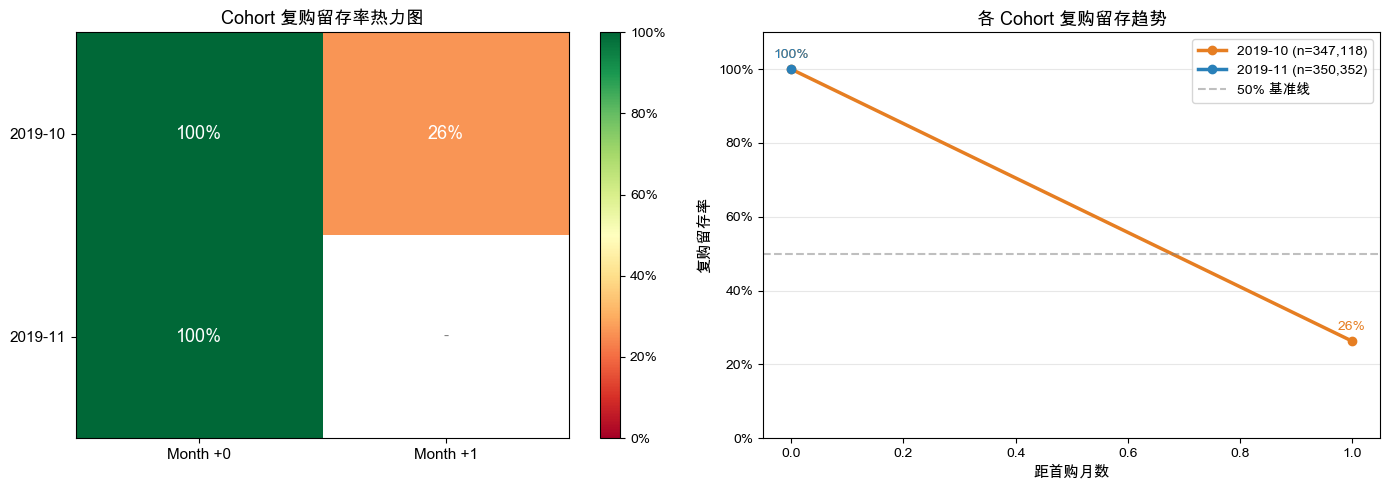


关键洞察
  [2019-10] Cohort 规模: 347,118 人
    → 次月复购留存率 (Month+1): 26.3%
  [2019-11] Cohort 规模: 350,352 人
    → 数据窗口内无 Month+1（11月 Cohort 正常）

注：此留存为纯购买口径（需再次下单才算留存），
    区别于 Block 13 的行为留存（浏览/加购/购买均算）。


In [13]:
# ══════════════════════════════════════════════════════════════════════
# Block 20：Cohort 留存曲线（全量数据，购买口径）
# 前置：Block 19.5 已运行，con_full 和 events 视图存在
# ══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

# ── 1. 全量购买事件按月聚合 ─────────────────────────────────────────
cohort_raw = con_full.execute("""
WITH purchases AS (
    SELECT
        CAST(user_id AS VARCHAR)                           AS user_id,
        DATE_TRUNC('month', event_time::TIMESTAMP)::DATE   AS purchase_month
    FROM events
    WHERE event_type = 'purchase'
),
first_purchase AS (
    SELECT user_id, MIN(purchase_month) AS cohort_month
    FROM purchases
    GROUP BY user_id
),
cohort_joined AS (
    SELECT
        p.user_id,
        f.cohort_month,
        p.purchase_month,
        DATEDIFF('month', f.cohort_month, p.purchase_month) AS period_number
    FROM purchases p
    JOIN first_purchase f ON p.user_id = f.user_id
)
SELECT
    cohort_month,
    period_number,
    COUNT(DISTINCT user_id) AS n_users
FROM cohort_joined
GROUP BY cohort_month, period_number
ORDER BY cohort_month, period_number
""").df()

cohort_raw['cohort_month'] = pd.to_datetime(cohort_raw['cohort_month']).dt.to_period('M')

# ── 2. 构建 pivot 表 ─────────────────────────────────────────────────
cohort_size  = cohort_raw[cohort_raw['period_number'] == 0].set_index('cohort_month')['n_users']
cohort_pivot = cohort_raw.pivot(index='cohort_month', columns='period_number', values='n_users')
cohort_ret   = cohort_pivot.divide(cohort_size, axis=0)

print("=" * 58)
print("Cohort 留存矩阵（人数）")
print("=" * 58)
print(cohort_pivot.to_string())
print()
print("=" * 58)
print("Cohort 留存率矩阵（复购口径）")
print("=" * 58)
print(cohort_ret.applymap(
    lambda x: f"{x:.1%}" if pd.notna(x) else "-").to_string())

# ── 3. 可视化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E67E22', '#2980B9', '#27AE60', '#8E44AD']

# 左：热力图
ax = axes[0]
data = cohort_ret.values.astype(float)
im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            tc = 'white' if val < 0.3 or val > 0.8 else 'black'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=13, fontweight='bold', color=tc)
        else:
            ax.text(j, i, '-', ha='center', va='center', fontsize=11, color='gray')
ax.set_xticks(range(cohort_ret.shape[1]))
ax.set_xticklabels([f'Month +{x}' for x in cohort_ret.columns], fontsize=11)
ax.set_yticks(range(cohort_ret.shape[0]))
ax.set_yticklabels([str(m) for m in cohort_ret.index], fontsize=11)
ax.set_title('Cohort 复购留存率热力图', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, format=mtick.PercentFormatter(1.0))

# 右：折线图
ax2 = axes[1]
for idx, (cm, row) in enumerate(cohort_ret.iterrows()):
    valid = row.dropna()
    if len(valid) == 0:
        continue
    size = cohort_size[cm]
    ax2.plot(valid.index, valid.values, marker='o', linewidth=2.5,
             color=colors[idx % len(colors)],
             label=f'{cm} (n={size:,})')
    for xp, yv in zip(valid.index, valid.values):
        ax2.annotate(f'{yv:.0%}', (xp, yv),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=10, color=colors[idx % len(colors)])

ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% 基准线')
ax2.set_xlabel('距首购月数', fontsize=11)
ax2.set_ylabel('复购留存率', fontsize=11)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title('各 Cohort 复购留存趋势', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'charts/cohort_retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. 关键洞察 ──────────────────────────────────────────────────────
print()
print("=" * 58)
print("关键洞察")
print("=" * 58)
for cm, row in cohort_ret.iterrows():
    valid = row.dropna()
    size  = cohort_size[cm]
    print(f"  [{cm}] Cohort 规模: {size:,} 人")
    if 1 in valid.index:
        print(f"    → 次月复购留存率 (Month+1): {valid[1]:.1%}")
    else:
        print(f"    → 数据窗口内无 Month+1（11月 Cohort 正常）")
print()
print("注：此留存为纯购买口径（需再次下单才算留存），")
print("    区别于 Block 13 的行为留存（浏览/加购/购买均算）。")

---
## 📦 Block 21：SKU 分析

基于全量数据分析产品（SKU）维度的销售集中度、转化漏斗和品牌表现。
分析仅覆盖有品类编码的 SKU（约占全量 60%），主力品类（electronics/appliances）标签完整，结论对主要品类成立。

**核心指标：**

| 字段 | 说明 |
|---|---|
| `sku_view / cart / purchase` | 浏览 / 加购 / 购买次数 |
| `sku_gmv` | 该 SKU 总 GMV |
| `view_to_purchase_cvr` | 浏览→购买转化率 |
| `cart_to_purchase_cvr` | 加购→购买转化率 |


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

全站 SKU 总数（浏览≥10次）: 160,594
已知品类+品牌 SKU（排行榜用）: 120,886

=== 销售集中度 ===
  贡献 80% GMV 的 SKU: 676 个 (0.4% of 全站 SKU)

=== Top 20 SKU（按购买次数，已过滤 unknown 品类/品牌）===
product_id    category   brand  sku_price  sku_view  sku_cart  sku_purchase     sku_gmv  view_to_purchase_cvr  cart_to_purchase_cvr
   1004856 electronics samsung     130.25    942167    133328         61265  7917932.74                  0.07                  0.46
   1004767 electronics samsung     246.65    861675    102215         44419 11004748.49                  0.05                  0.43
   1005115 electronics   apple     955.84    910725     80923         34787 33032381.67                  0.04                  0.43
   4804056 electronics   apple     161.63    497431     77400         30181  4921646.06                  0.06                  0.39
   1004833 electronics samsung     170.87    450464     56048         26183  4494994.25                  0.06                  0.47
   1002544 electronics   apple     460.63    409169 

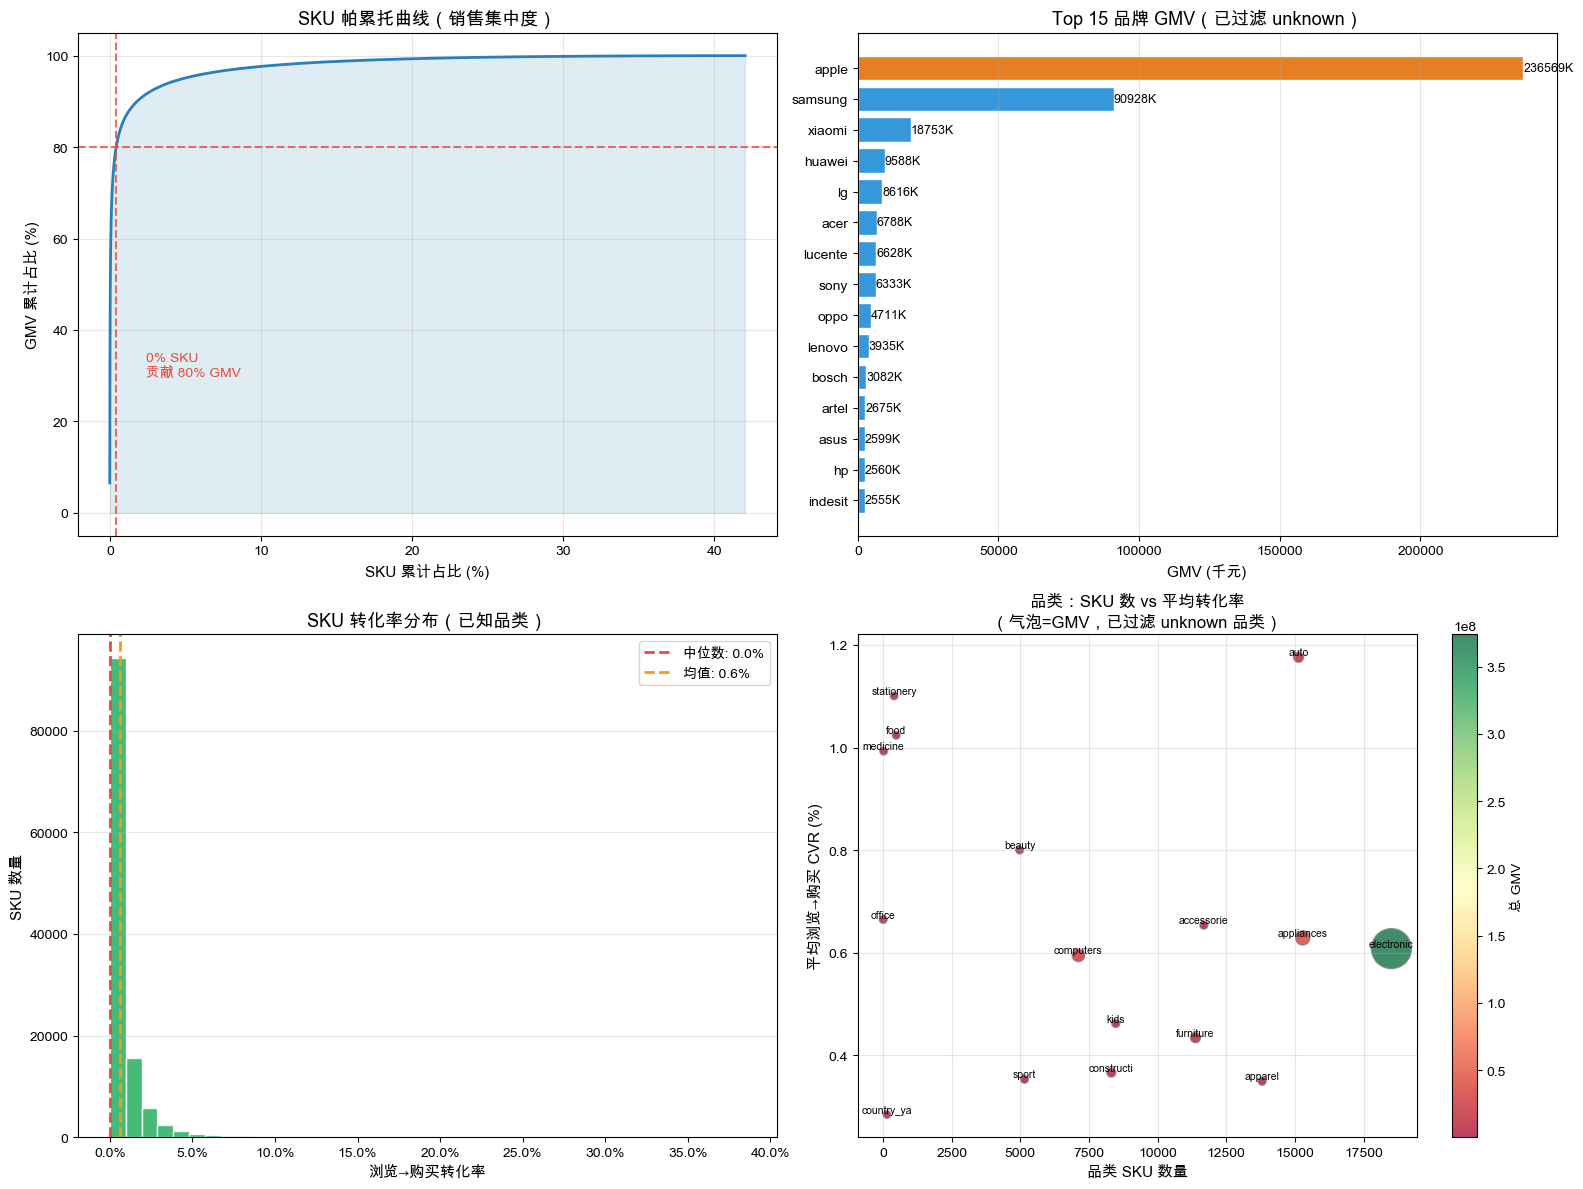

✅ SKU 分析图已保存

Top 品牌 (GMV): apple，GMV=236,568,925


In [22]:
# ══════════════════════════════════════════════════════════════════
# Block 21：SKU 分析（全量数据，过滤 unknown 品类/品牌/价格异常）
# 前置：Block 19.5
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

# ── 1. SKU 级聚合（全量）────────────────────────────────────────────
sku_raw = con_full.execute("""
SELECT
    CAST(product_id AS VARCHAR)                               AS product_id,
    ANY_VALUE(category_main)                                  AS category,
    ANY_VALUE(brand)                                          AS brand,
    COUNT(*) FILTER (WHERE event_type='view')                 AS sku_view,
    COUNT(*) FILTER (WHERE event_type='cart')                 AS sku_cart,
    COUNT(*) FILTER (WHERE event_type='purchase')             AS sku_purchase,
    SUM(price) FILTER (WHERE event_type='purchase')           AS sku_gmv,
    MEDIAN(price) FILTER (WHERE event_type='purchase')        AS sku_price,
    COUNT(DISTINCT user_id) FILTER (WHERE event_type='view')  AS unique_viewers
FROM events
WHERE price > 0
GROUP BY product_id
HAVING COUNT(*) FILTER (WHERE event_type='view') >= 10
""").df()

# 过滤 unknown 品类和品牌（保留用于全局指标，过滤用于排行榜）
sku_all    = sku_raw.copy()
sku_ranked = sku_raw[
    (sku_raw['category'] != 'unknown') &
    (sku_raw['brand'] != 'unknown')
].copy()

sku_ranked['view_to_purchase_cvr'] = np.where(
    sku_ranked['sku_view'] > 0,
    sku_ranked['sku_purchase'] / sku_ranked['sku_view'], 0)
sku_ranked['cart_to_purchase_cvr'] = np.where(
    sku_ranked['sku_cart'] > 0,
    sku_ranked['sku_purchase'] / sku_ranked['sku_cart'], 0)
sku_ranked['unique_user_ratio'] = (
    sku_ranked['unique_viewers'] / (sku_ranked['sku_view'] + 1))

print(f"全站 SKU 总数（浏览≥10次）: {len(sku_all):,}")
print(f"已知品类+品牌 SKU（排行榜用）: {len(sku_ranked):,}")

# ── 2. 帕累托：销售集中度 ────────────────────────────────────────────
sku_sorted = sku_all.sort_values('sku_gmv', ascending=False).reset_index(drop=True)
sku_sorted['gmv_cum_pct'] = sku_sorted['sku_gmv'].cumsum() / sku_sorted['sku_gmv'].sum()
sku_sorted['sku_pct']     = (sku_sorted.index + 1) / len(sku_sorted)
idx_80    = (sku_sorted['gmv_cum_pct'] >= 0.80).idxmax()
sku80_pct = sku_sorted.loc[idx_80, 'sku_pct']

print(f"\n=== 销售集中度 ===")
print(f"  贡献 80% GMV 的 SKU: {idx_80+1:,} 个 ({sku80_pct:.1%} of 全站 SKU)")

# ── 3. Top 20 SKU（排行榜过滤 unknown）──────────────────────────────
top20 = sku_ranked.nlargest(20, 'sku_purchase')[
    ['product_id','category','brand','sku_price',
     'sku_view','sku_cart','sku_purchase','sku_gmv',
     'view_to_purchase_cvr','cart_to_purchase_cvr']]
print("\n=== Top 20 SKU（按购买次数，已过滤 unknown 品类/品牌）===")
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
print(top20.to_string(index=False))

# ── 4. 品牌表现（过滤 unknown 品牌）────────────────────────────────
brand_agg = sku_ranked.groupby('brand').agg(
    sku_count  =('product_id','nunique'),
    total_gmv  =('sku_gmv','sum'),
    total_purch=('sku_purchase','sum'),
    avg_cvr    =('view_to_purchase_cvr','mean'),
    avg_price  =('sku_price','median'),
).reset_index()
top_brands = brand_agg.nlargest(15, 'total_gmv')

# ── 5. 可视化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 左上：帕累托曲线
ax = axes[0, 0]
ax.plot(sku_sorted['sku_pct']*100, sku_sorted['gmv_cum_pct']*100,
        color='#2980B9', linewidth=2)
ax.axhline(80, color='#E74C3C', linestyle='--', alpha=0.8)
ax.axvline(sku80_pct*100, color='#E74C3C', linestyle='--', alpha=0.8)
ax.fill_between(sku_sorted['sku_pct']*100, sku_sorted['gmv_cum_pct']*100,
                alpha=0.15, color='#2980B9')
ax.text(sku80_pct*100+2, 30,
        f'{sku80_pct:.0%} SKU\n贡献 80% GMV',
        fontsize=10, color='#E74C3C')
ax.set_xlabel('SKU 累计占比 (%)', fontsize=11)
ax.set_ylabel('GMV 累计占比 (%)', fontsize=11)
ax.set_title('SKU 帕累托曲线（销售集中度）', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# 右上：Top 15 品牌 GMV
ax = axes[0, 1]
clr = ['#E67E22' if i==0 else '#3498DB' for i in range(len(top_brands))]
bars = ax.barh(top_brands['brand'][::-1], top_brands['total_gmv'][::-1]/1000,
               color=clr[::-1], edgecolor='white')
ax.set_xlabel('GMV (千元)', fontsize=11)
ax.set_title('Top 15 品牌 GMV（已过滤 unknown）', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_brands['total_gmv'][::-1]/1000):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}K', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# 左下：SKU CVR 分布
ax = axes[1, 0]
cvr = sku_ranked['view_to_purchase_cvr'].clip(0, 0.5)
ax.hist(cvr, bins=40, color='#27AE60', edgecolor='white', alpha=0.85)
ax.axvline(cvr.median(), color='#E74C3C', linewidth=2, linestyle='--',
           label=f'中位数: {cvr.median():.1%}')
ax.axvline(cvr.mean(), color='#F39C12', linewidth=2, linestyle='--',
           label=f'均值: {cvr.mean():.1%}')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('浏览→购买转化率', fontsize=11)
ax.set_ylabel('SKU 数量', fontsize=11)
ax.set_title('SKU 转化率分布（已知品类）', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 右下：品类 SKU 数 × 平均转化率气泡
ax = axes[1, 1]
cat_sku = sku_ranked.groupby('category').agg(
    sku_count=('product_id','nunique'),
    avg_cvr  =('view_to_purchase_cvr','mean'),
    total_gmv=('sku_gmv','sum'),
).reset_index()
cat_sku = cat_sku[cat_sku['sku_count'] >= 5]
sc = ax.scatter(cat_sku['sku_count'], cat_sku['avg_cvr']*100,
                s=cat_sku['total_gmv']/cat_sku['total_gmv'].max()*800+30,
                c=cat_sku['total_gmv'], cmap='RdYlGn', alpha=0.75, edgecolors='gray')
for _, row in cat_sku.iterrows():
    ax.annotate(row['category'][:10], (row['sku_count'], row['avg_cvr']*100),
                fontsize=7.5, ha='center', va='bottom')
plt.colorbar(sc, ax=ax, label='总 GMV')
ax.set_xlabel('品类 SKU 数量', fontsize=11)
ax.set_ylabel('平均浏览→购买 CVR (%)', fontsize=11)
ax.set_title('品类：SKU 数 vs 平均转化率\n（气泡=GMV，已过滤 unknown 品类）',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'charts/sku_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ SKU 分析图已保存")
print(f"\nTop 品牌 (GMV): {top_brands.iloc[0]['brand']}，GMV={top_brands.iloc[0]['total_gmv']:,.0f}")

---
## 🔥 Block 22：爆款预测（逻辑回归，时间隔离版）

基于全量数据，用 SKU 在 **10月**的行为质量信号预测其在 **11月**是否成为爆款（购买量 Top 20%）。

### 特征设计原则

特征与标签严格跨月隔离：特征窗口 = 10月，标签窗口 = 11月。这有两个作用：一是消除同期循环相关（总加购量和总购买量在同一窗口内天然正相关）；二是将 11月大促的影响限制在标签侧，特征侧不受污染。

所有计数型特征均除以 10月活跃天数归一化，使新上架 SKU 和老 SKU 在同一量纲下可比。

| 特征 | 计算方式 | 说明 |
|---|---|---|
| `log_cart_per_day` | log(月总加购 / 活跃天数 + 1) | 日均加购体量，消除在架时长偏差 |
| `cart_to_view_ratio` | 月总加购 / 月总浏览 | 纯转化质量信号，无体量偏差 |
| `unique_user_ratio` | 独立浏览用户 / 总浏览次数 | 浏览者多样性，高值=自然传播 |
| `log_price` | log(中位成交价 + 1) | 价格档位 |
| `category_encoded` | LabelEncoder | 品类基础转化率差异 |

> **爆款定义**：11月购买次数在「有购买记录的 SKU」中位于 Top 20%。  
> **样本范围**：10月出现（浏览≥5次）且品类/品牌已知的 SKU，取与 11月购买数据的交集。


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

10月出现的已知品类 SKU: 99,960
其中 11月有购买记录: 34,099 (34.1%)
11月零购买: 65,861 (65.9%)

爆款阈值（11月购买次数 Top 20%）: ≥ 10 次
爆款 SKU 数: 6,831 / 99,960 (6.8%)
（含 11月零购买 SKU，正例率低于原版属正常）

5折交叉验证 AUC: 0.904 ± 0.003
5折交叉验证 AP:  0.562 ± 0.008

=== 特征系数（逻辑回归，时间隔离版）===
           feature  coefficient
  log_cart_per_day         1.95
         log_price         1.20
  category_encoded        -0.04
 unique_user_ratio        -0.48
cart_to_view_ratio        -0.53

=== 分类报告 ===
              precision    recall  f1-score   support

         非爆款       0.99      0.81      0.89     93129
          爆款       0.25      0.86      0.38      6831

    accuracy                           0.81     99960
   macro avg       0.62      0.84      0.64     99960
weighted avg       0.94      0.81      0.85     99960



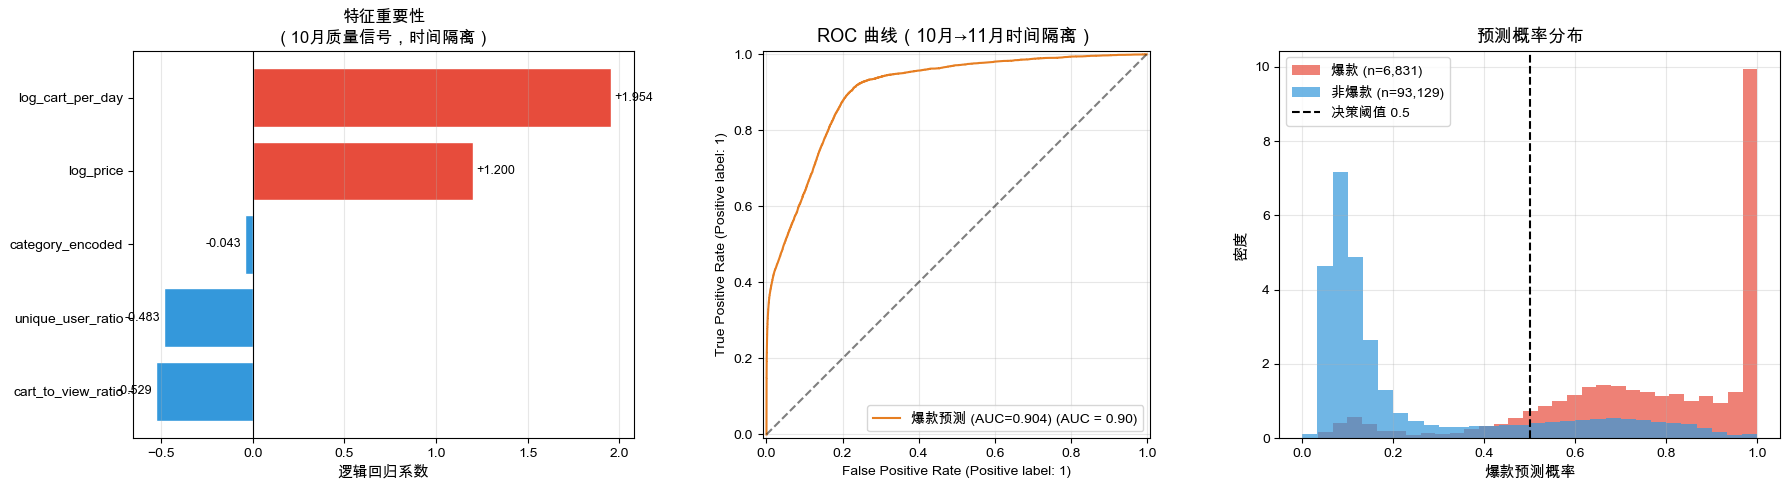

✅ 爆款预测图已保存

=== Top 10 潜在爆款（10月信号强但11月未进 Top 20%）===
product_id     category    brand  sku_price  oct_view  oct_purchase  nov_purchase  cart_to_view_ratio  bestseller_prob
  26900073        sport   domyos     167.55      2067            45          7.00                0.06             1.00
   8500088 construction   hubert     535.15      5055           109          7.00                0.04             1.00
   3700956   appliances   xiaomi     486.49      6558            79          7.00                0.02             1.00
  17800122    computers     zeta     125.63      7022            75          0.00                0.02             1.00
   3200201   appliances elenberg      46.31      5255           161          7.00                0.03             1.00
  17800124    computers     zeta     141.03      4367            60          1.00                0.03             1.00
   1306659    computers       hp     321.73      3232            71          1.00                0.04             

In [26]:
# ══════════════════════════════════════════════════════════════════
# Block 22：爆款预测（逻辑回归，10月特征 → 11月标签，时间隔离）
# 前置：Block 19.5
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import RocCurveDisplay, classification_report
from sklearn.pipeline import Pipeline

# ── 1. 10月 SKU 特征（活跃天数归一化）────────────────────────────
oct_raw = con_full.execute("""
SELECT
    CAST(product_id AS VARCHAR)                                    AS product_id,
    ANY_VALUE(category_main)                                       AS category,
    ANY_VALUE(brand)                                               AS brand,
    COUNT(*) FILTER (WHERE event_type='view')                     AS oct_view,
    COUNT(*) FILTER (WHERE event_type='cart')                     AS oct_cart,
    COUNT(*) FILTER (WHERE event_type='purchase')                 AS oct_purchase,
    MEDIAN(price) FILTER (WHERE event_type='purchase')            AS sku_price,
    COUNT(DISTINCT user_id) FILTER (WHERE event_type='view')      AS unique_viewers,
    COUNT(DISTINCT CAST(event_time AS DATE))                       AS active_days_oct
FROM events
WHERE month = 'Oct' AND price > 0
  AND category_main != 'unknown' AND brand != 'unknown'
GROUP BY product_id
HAVING COUNT(*) FILTER (WHERE event_type='view') >= 5
""").df()

# ── 2. 11月购买量（标签来源）─────────────────────────────────────
nov_purch = con_full.execute("""
SELECT CAST(product_id AS VARCHAR) AS product_id,
       COUNT(*) FILTER (WHERE event_type='purchase') AS nov_purchase
FROM events
WHERE month = 'Nov'
GROUP BY product_id
""").df()

# ── 3. 合并，只保留 10月出现的 SKU ─────────────────────────────
feat_df = oct_raw.merge(nov_purch, on='product_id', how='left')
feat_df['nov_purchase'] = feat_df['nov_purchase'].fillna(0)

print(f"10月出现的已知品类 SKU: {len(feat_df):,}")
print(f"其中 11月有购买记录: {(feat_df['nov_purchase']>=1).sum():,} ({(feat_df['nov_purchase']>=1).mean():.1%})")
print(f"11月零购买: {(feat_df['nov_purchase']==0).sum():,} ({(feat_df['nov_purchase']==0).mean():.1%})")

# ── 4. 特征工程（日均归一化）─────────────────────────────────────
feat_df['active_days_oct'] = feat_df['active_days_oct'].clip(lower=1)
feat_df['cart_per_day']       = feat_df['oct_cart'] / feat_df['active_days_oct']
feat_df['log_cart_per_day']   = np.log1p(feat_df['cart_per_day'])
feat_df['cart_to_view_ratio'] = feat_df['oct_cart'] / (feat_df['oct_view'] + 1)
feat_df['unique_user_ratio']  = feat_df['unique_viewers'] / (feat_df['oct_view'] + 1)
feat_df['log_price']          = np.log1p(feat_df['sku_price'].fillna(0).clip(0))

le = LabelEncoder()
feat_df['category_encoded'] = le.fit_transform(feat_df['category'].fillna('other'))

# ── 5. 标签：11月购买量 Top 20%（仅在有购买的 SKU 中算分位）────
sku_w_purch = feat_df[feat_df['nov_purchase'] >= 1]
threshold   = max(sku_w_purch['nov_purchase'].quantile(0.80), 2)
feat_df['is_bestseller'] = (feat_df['nov_purchase'] >= threshold).astype(int)

print(f"\n爆款阈值（11月购买次数 Top 20%）: ≥ {threshold:.0f} 次")
print(f"爆款 SKU 数: {feat_df['is_bestseller'].sum():,} / {len(feat_df):,} "
      f"({feat_df['is_bestseller'].mean():.1%})")
print(f"（含 11月零购买 SKU，正例率低于原版属正常）")

if feat_df['is_bestseller'].nunique() < 2:
    print("⚠️  标签只有一类，请检查数据量")
else:
    # ── 6. 模型训练（5折 CV）─────────────────────────────────────
    FEATURES = ['log_cart_per_day', 'cart_to_view_ratio',
                'unique_user_ratio', 'log_price', 'category_encoded']

    X = feat_df[FEATURES].fillna(0).values
    y = feat_df['is_bestseller'].values

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, class_weight='balanced',
                                      random_state=42, C=1.0))
    ])
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    cv_ap  = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision')

    print(f"\n5折交叉验证 AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
    print(f"5折交叉验证 AP:  {cv_ap.mean():.3f} ± {cv_ap.std():.3f}")

    pipeline.fit(X, y)
    clf     = pipeline.named_steps['clf']
    coef_df = pd.DataFrame({'feature': FEATURES,
                             'coefficient': clf.coef_[0]}
                           ).sort_values('coefficient', ascending=False)
    print("\n=== 特征系数（逻辑回归，时间隔离版）===")
    print(coef_df.to_string(index=False))

    y_prob = pipeline.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    print("\n=== 分类报告 ===")
    print(classification_report(y, y_pred, target_names=['非爆款','爆款']))

    # ── 7. 可视化 ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 左：特征系数
    ax = axes[0]
    clrs = ['#E74C3C' if c > 0 else '#3498DB' for c in coef_df['coefficient']]
    ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1],
            color=clrs[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    for i, (_, row) in enumerate(coef_df[::-1].iterrows()):
        xp = row['coefficient'] + 0.02 if row['coefficient'] >= 0 else row['coefficient'] - 0.02
        ax.text(xp, i, f"{row['coefficient']:+.3f}", va='center',
                ha='left' if row['coefficient'] >= 0 else 'right', fontsize=9)
    ax.set_xlabel('逻辑回归系数', fontsize=11)
    ax.set_title('特征重要性\n（10月质量信号，时间隔离）', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # 中：ROC 曲线
    ax = axes[1]
    RocCurveDisplay.from_predictions(
        y, y_prob, ax=ax,
        name=f'爆款预测 (AUC={cv_auc.mean():.3f})',
        color='#E67E22')
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title('ROC 曲线（10月→11月时间隔离）', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)

    # 右：预测概率分布
    ax = axes[2]
    ax.hist(y_prob[y==1], bins=30, alpha=0.7, color='#E74C3C',
            label=f'爆款 (n={y.sum():,})', density=True)
    ax.hist(y_prob[y==0], bins=30, alpha=0.7, color='#3498DB',
            label=f'非爆款 (n={(y==0).sum():,})', density=True)
    ax.axvline(0.5, color='black', linestyle='--', label='决策阈值 0.5')
    ax.set_xlabel('爆款预测概率', fontsize=11)
    ax.set_ylabel('密度', fontsize=11)
    ax.set_title('预测概率分布', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(SAVE_PATH + 'charts/bestseller_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 爆款预测图已保存")

    # ── 8. 潜在爆款：10月高分但 11月未进 Top 20%（或 11月零购买）──
    feat_df['bestseller_prob'] = y_prob
    potential = feat_df[
        (feat_df['is_bestseller'] == 0) &
        (feat_df['bestseller_prob'] >= 0.6) &
        (feat_df['sku_price'] > 0)
    ].nlargest(10, 'bestseller_prob')

    print("\n=== Top 10 潜在爆款（10月信号强但11月未进 Top 20%）===")
    print(potential[['product_id','category','brand','sku_price',
                      'oct_view','oct_purchase','nov_purchase',
                      'cart_to_view_ratio','bestseller_prob']].to_string(index=False))


---
## 📊 Block 23：库存管理分析

基于全量购买数据计算各 SKU 的日销均值与波动，输出安全库存和再订购点建议，并对 SKU 进行风险分级。

**公式：**
- 安全库存 = Z × σ_日销 × √Lead_Time
- 再订购点 (ROP) = μ_日销 × Lead_Time + 安全库存

**参数**：Lead Time = 7 天，Z = 1.65（95% 服务水平），品类过滤 unknown


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

库存分析 SKU 数量: 19,636（已知品类，活跃≥5天）
  HIGH RISK  : 1,235  (6.3%)
  MEDIUM RISK: 7,099  (36.2%)
  LOW RISK   : 11,302  (57.6%)

=== 品类库存概览（按日均 GMV 排序，已过滤 unknown）===
    category  sku_count  avg_daily_units  avg_safety_stock  avg_rop  high_risk_pct  total_gmv_per_day
 electronics       3734             5.37             16.60    54.22           0.06         7529149.77
  appliances       3922             2.02              7.70    21.82           0.13         1400493.92
   computers       1378             1.90              6.10    19.42           0.07         1046556.35
   furniture       1841             1.85              5.89    18.82           0.08          727117.23
        auto       3184             1.87              5.16    18.26           0.02          550779.07
 accessories       1497             1.54              3.78    14.57           0.03          392738.13
construction       1014             1.73              5.18    17.31           0.05          293808.58
     apparel       1054

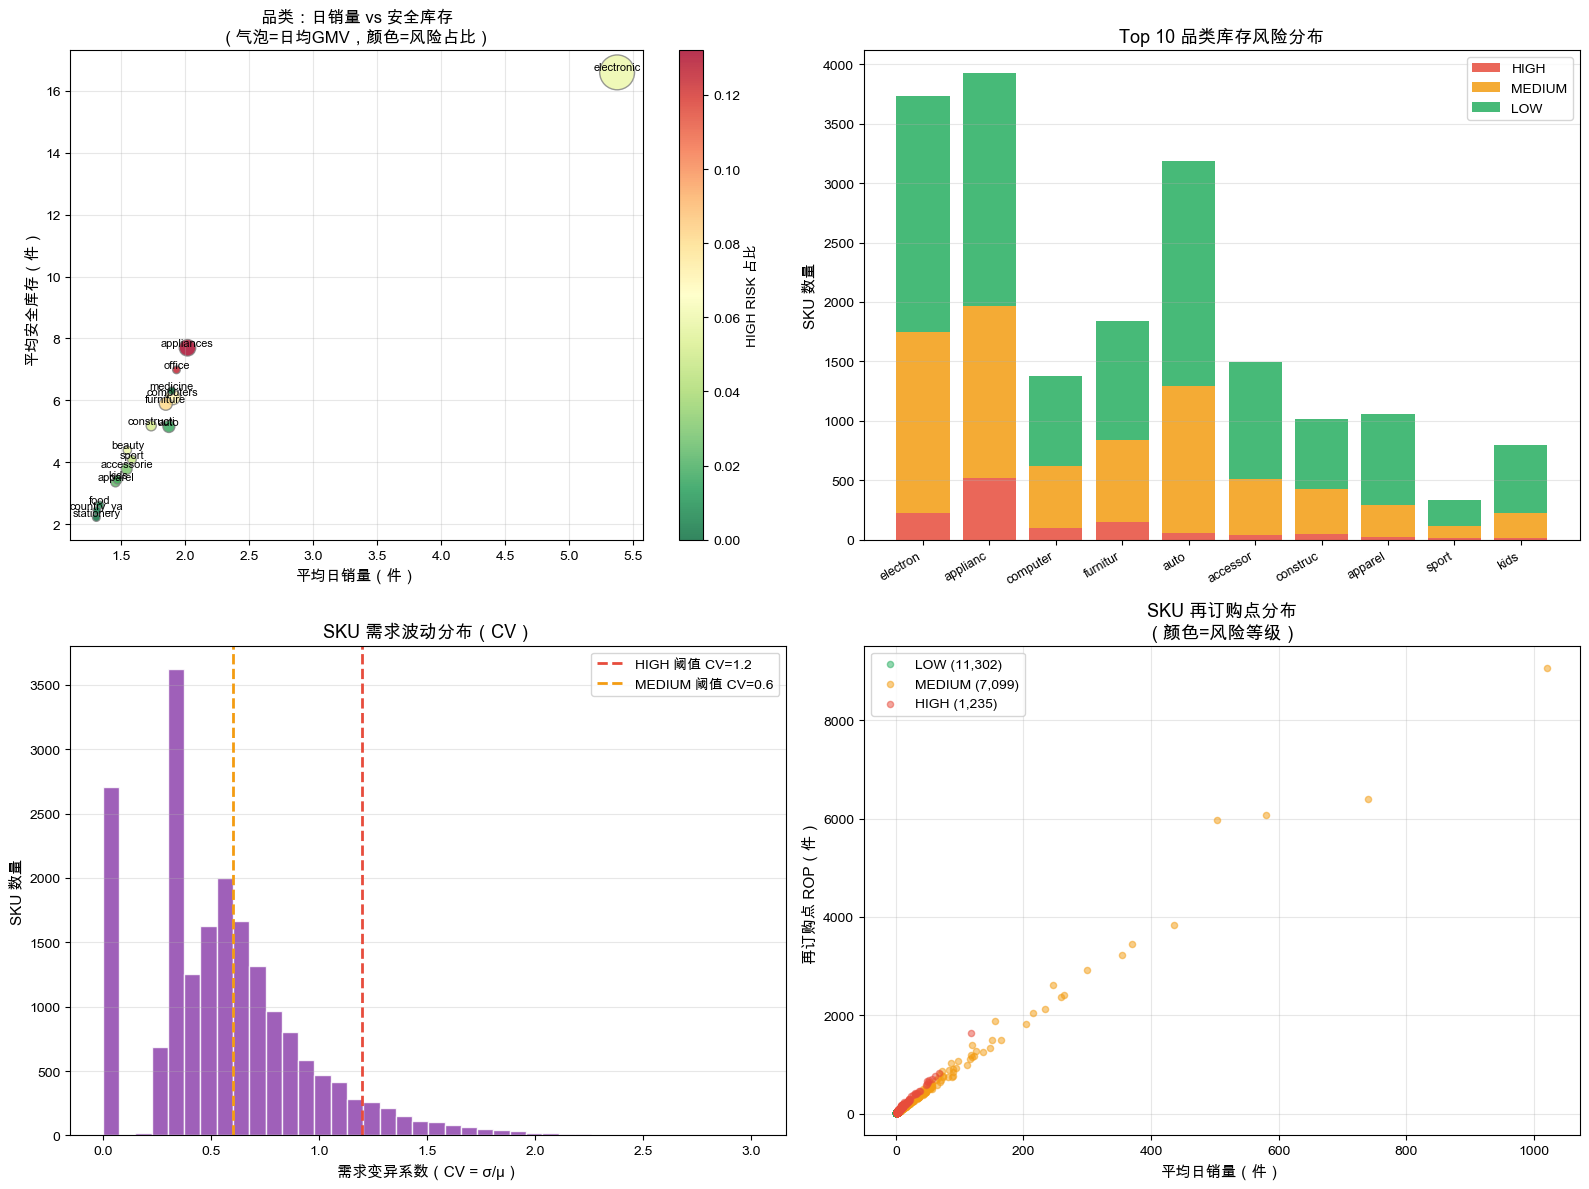

✅ 库存管理分析图已保存

库存管理运营建议
1. electronics 品类日均 GMV 最高，优先保障安全库存
2. [appliances] HIGH RISK 占比 13%，建议将 Z 提升至 1.96（99% 服务水平）
2. [office] HIGH RISK 占比 12%，建议将 Z 提升至 1.96（99% 服务水平）
2. [furniture] HIGH RISK 占比 8%，建议将 Z 提升至 1.96（99% 服务水平）
3. Lead Time 假设 7 天——供应商实际周期若更长，ROP 需等比放大
4. LOW RISK SKU 可转 JIT 补货模式，降低库存占用成本


In [24]:
# ══════════════════════════════════════════════════════════════════
# Block 23：库存管理分析（全量数据，过滤 unknown 品类）
# 前置：Block 19.5
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

LEAD_TIME_DAYS    = 7
Z_SCORE           = 1.65
MIN_PURCHASE_DAYS = 5

# ── 1. 全量每日 SKU 购买量 ──────────────────────────────────────────
daily_raw = con_full.execute("""
SELECT
    CAST(product_id AS VARCHAR)          AS product_id,
    CAST(event_time AS DATE)             AS date_ts,
    COUNT(*)                             AS daily_units,
    ANY_VALUE(category_main)             AS category,
    ANY_VALUE(brand)                     AS brand,
    MEDIAN(price)                        AS price
FROM events
WHERE event_type = 'purchase'
  AND price > 0
  AND category_main != 'unknown'
GROUP BY product_id, CAST(event_time AS DATE)
""").df()

daily_raw['date_ts'] = pd.to_datetime(daily_raw['date_ts'])

# ── 2. SKU 统计量 ────────────────────────────────────────────────────
sku_stats = daily_raw.groupby('product_id').agg(
    mean_daily = ('daily_units','mean'),
    std_daily  = ('daily_units','std'),
    active_days= ('daily_units','count'),
    total_units= ('daily_units','sum'),
    price      = ('price','median'),
    category   = ('category', lambda x: x.mode()[0] if len(x.mode())>0 else 'unknown'),
    brand      = ('brand',    lambda x: x.mode()[0] if len(x.mode())>0 else 'unknown'),
).reset_index()
sku_stats['std_daily'] = sku_stats['std_daily'].fillna(0)
sku_stats = sku_stats[
    (sku_stats['active_days'] >= MIN_PURCHASE_DAYS) &
    (sku_stats['category'] != 'unknown')
].copy()

# ── 3. 安全库存 & ROP ────────────────────────────────────────────────
sku_stats['safety_stock'] = (
    Z_SCORE * sku_stats['std_daily'] * np.sqrt(LEAD_TIME_DAYS)
).round(1)
sku_stats['reorder_point'] = (
    sku_stats['mean_daily'] * LEAD_TIME_DAYS + sku_stats['safety_stock']
).round(1)
sku_stats['gmv_per_day'] = sku_stats['mean_daily'] * sku_stats['price']
sku_stats['cv'] = np.where(
    sku_stats['mean_daily'] > 0,
    sku_stats['std_daily'] / sku_stats['mean_daily'], 999)

# ── 4. 风险分级 ──────────────────────────────────────────────────────
speed_threshold = sku_stats['mean_daily'].quantile(0.75)
CV_H, CV_M     = 1.2, 0.6

def risk_level(row):
    if row['cv'] > CV_H:
        return 'HIGH'
    elif row['mean_daily'] >= speed_threshold or row['cv'] > CV_M:
        return 'MEDIUM'
    return 'LOW'

sku_stats['risk_level'] = sku_stats.apply(risk_level, axis=1)

print(f"库存分析 SKU 数量: {len(sku_stats):,}（已知品类，活跃≥{MIN_PURCHASE_DAYS}天）")
print(f"  HIGH RISK  : {(sku_stats['risk_level']=='HIGH').sum():,}  "
      f"({(sku_stats['risk_level']=='HIGH').mean():.1%})")
print(f"  MEDIUM RISK: {(sku_stats['risk_level']=='MEDIUM').sum():,}  "
      f"({(sku_stats['risk_level']=='MEDIUM').mean():.1%})")
print(f"  LOW RISK   : {(sku_stats['risk_level']=='LOW').sum():,}  "
      f"({(sku_stats['risk_level']=='LOW').mean():.1%})")

# ── 5. 品类级汇总 ────────────────────────────────────────────────────
cat_inv = sku_stats.groupby('category').agg(
    sku_count        =('product_id','count'),
    avg_daily_units  =('mean_daily','mean'),
    avg_safety_stock =('safety_stock','mean'),
    avg_rop          =('reorder_point','mean'),
    total_gmv_per_day=('gmv_per_day','sum'),
    high_risk_count  =('risk_level', lambda x: (x=='HIGH').sum()),
    avg_cv           =('cv', lambda x: x[x<999].mean()),
).reset_index()
cat_inv['high_risk_pct'] = cat_inv['high_risk_count'] / cat_inv['sku_count']
cat_inv = cat_inv.sort_values('total_gmv_per_day', ascending=False)

print("\n=== 品类库存概览（按日均 GMV 排序，已过滤 unknown）===")
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
print(cat_inv[['category','sku_count','avg_daily_units','avg_safety_stock',
               'avg_rop','high_risk_pct','total_gmv_per_day']].to_string(index=False))

print("\n=== TOP 15 高风险 SKU（HIGH RISK，按日均 GMV 排序）===")
high_risk = sku_stats[sku_stats['risk_level']=='HIGH'].nlargest(15,'gmv_per_day')
print(high_risk[['product_id','category','brand','price',
                 'mean_daily','cv','safety_stock','reorder_point',
                 'gmv_per_day']].to_string(index=False))

# ── 6. 可视化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 左上：品类日销 vs 安全库存（气泡=GMV，颜色=高风险占比）
ax = axes[0, 0]
cat_p = cat_inv[cat_inv['sku_count'] >= 3]
sc = ax.scatter(cat_p['avg_daily_units'], cat_p['avg_safety_stock'],
                s=cat_p['total_gmv_per_day']/cat_p['total_gmv_per_day'].max()*600+30,
                c=cat_p['high_risk_pct'], cmap='RdYlGn_r', alpha=0.8, edgecolors='gray')
for _, row in cat_p.iterrows():
    ax.annotate(row['category'][:10], (row['avg_daily_units'], row['avg_safety_stock']),
                fontsize=8, ha='center', va='bottom')
plt.colorbar(sc, ax=ax, label='HIGH RISK 占比')
ax.set_xlabel('平均日销量（件）', fontsize=11)
ax.set_ylabel('平均安全库存（件）', fontsize=11)
ax.set_title('品类：日销量 vs 安全库存\n（气泡=日均GMV，颜色=风险占比）',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# 右上：Top 10 品类风险堆叠柱
ax = axes[0, 1]
risk_cat = sku_stats.groupby(['category','risk_level']).size().unstack(fill_value=0)
risk_cat = risk_cat.reindex(cat_inv['category'].head(10)).dropna()
clrs_r   = {'HIGH':'#E74C3C','MEDIUM':'#F39C12','LOW':'#27AE60'}
btm      = np.zeros(len(risk_cat))
for lvl in ['HIGH','MEDIUM','LOW']:
    if lvl in risk_cat.columns:
        ax.bar(range(len(risk_cat)), risk_cat[lvl].values,
               bottom=btm, label=lvl, color=clrs_r[lvl], alpha=0.85)
        btm += risk_cat[lvl].values
ax.set_xticks(range(len(risk_cat)))
ax.set_xticklabels([c[:8] for c in risk_cat.index], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('SKU 数量', fontsize=11)
ax.set_title('Top 10 品类库存风险分布', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 左下：CV 分布
ax = axes[1, 0]
cv_v = sku_stats['cv'][sku_stats['cv'] < 5]
ax.hist(cv_v, bins=40, color='#8E44AD', edgecolor='white', alpha=0.85)
ax.axvline(CV_H, color='#E74C3C', linestyle='--', linewidth=2,
           label=f'HIGH 阈值 CV={CV_H}')
ax.axvline(CV_M, color='#F39C12', linestyle='--', linewidth=2,
           label=f'MEDIUM 阈值 CV={CV_M}')
ax.set_xlabel('需求变异系数（CV = σ/μ）', fontsize=11)
ax.set_ylabel('SKU 数量', fontsize=11)
ax.set_title('SKU 需求波动分布（CV）', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 右下：ROP vs 日均销量
ax = axes[1, 1]
clr_map = {'LOW':'#27AE60','MEDIUM':'#F39C12','HIGH':'#E74C3C'}
for lvl, zo in [('LOW',1),('MEDIUM',2),('HIGH',3)]:
    sub = sku_stats[(sku_stats['risk_level']==lvl) & (sku_stats['cv']<5)]
    ax.scatter(sub['mean_daily'], sub['reorder_point'],
               c=clr_map[lvl], alpha=0.5, s=20,
               label=f'{lvl} ({len(sub):,})', zorder=zo)
ax.set_xlabel('平均日销量（件）', fontsize=11)
ax.set_ylabel('再订购点 ROP（件）', fontsize=11)
ax.set_title('SKU 再订购点分布\n（颜色=风险等级）', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'charts/inventory_management.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 库存管理分析图已保存")

print()
print("=" * 55)
print("库存管理运营建议")
print("=" * 55)
if len(cat_inv) > 0:
    top_cat = cat_inv.iloc[0]['category']
    print(f"1. {top_cat} 品类日均 GMV 最高，优先保障安全库存")
high_risk_cats = cat_inv[cat_inv['high_risk_pct'] > 0].nlargest(3,'high_risk_pct')
for _, row in high_risk_cats.iterrows():
    print(f"2. [{row['category']}] HIGH RISK 占比 {row['high_risk_pct']:.0%}，"
          f"建议将 Z 提升至 1.96（99% 服务水平）")
print(f"3. Lead Time 假设 {LEAD_TIME_DAYS} 天——供应商实际周期若更长，ROP 需等比放大")
print(f"4. LOW RISK SKU 可转 JIT 补货模式，降低库存占用成本")